# Lab 9 Tutorial - Training a CNN on CIFAR-10

In this lab you will train a simple CNN on CIFAR-10 from scratch. We are going to compare the different kind of strategies in the following order:

- initialization
- batch size
- optimizer
- learning rate
- scheduling
- normalization
- regularization
- hyperparameter tuning
- transfer learning

In terms of time limit, choose **lab** mode for the lab demo. If you have powerful GPU (or Colab Pro subscriber), you can choose **take home** mode.


## Notebook map and runtime modes

- **`MODE = "lab"`** uses smaller subsets and fewer epochs.
- **`MODE = "take_home"`** uses larger subsets and more epochs.
- **`RUN_TRANSFER_LEARNING = True`** by default
- **`RUN_FULL_HPARAM_SEARCH = True`** by default.


In [1]:

import os
import math
import time
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_fscore_support,
)

SEED = 472
MODE = "lab"              # change to "take_home" for larger subsets and longer runs
RUN_TRANSFER_LEARNING = True
RUN_FULL_HPARAM_SEARCH = True

SETTINGS = {
    "lab": {
        "train_size": 5000,
        "val_size": 1000,
        "test_size": 1000,
        "base_epochs": 10,
        "long_epochs": 20,
        "reg_epochs": 15,
        "tuning_trials": 8,
    },
    "take_home": {
        "train_size": 15000,
        "val_size": 3000,
        "test_size": 3000,
        "base_epochs": 20,
        "long_epochs": 50,
        "reg_epochs": 30,
        "tuning_trials": 15,
    },
}

CFG = SETTINGS[MODE]
DATA_DIR = Path("./data")
NUM_CLASSES = 10
DEFAULT_BATCH_SIZE = 128
NUM_WORKERS = 2 if os.cpu_count() and os.cpu_count() > 2 else 0

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Mode: {MODE}")
print(CFG)


Device: cuda
Mode: lab
{'train_size': 5000, 'val_size': 1000, 'test_size': 1000, 'base_epochs': 10, 'long_epochs': 20, 'reg_epochs': 15, 'tuning_trials': 8}


## 1. The big picture: one training loop

A PyTorch training loop always follows the same logic:

1. initialize the model parameters  
2. create mini-batches from the training set  
3. run a forward pass  
4. compute the loss  
5. backpropagate gradients  
6. update parameters with an optimizer  
7. repeat for many epochs  
8. use the validation set to compare settings


```python
for epoch in range(num_epochs):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

    # optional scheduler step
    # validate after each epoch
```


## 2. Build the CIFAR-10 data pipeline

We split data into 70/15/15 for **train**/**validation**/**test**.

We also keep the split **fixed across all experiments**.

We define two training pipelines:

- **plain training transform**: only tensor conversion + normalization  
- **augmented training transform**: random crop + random horizontal flip + normalization  


In [2]:

plain_train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

aug_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

def make_split_indices(train_size: int, val_size: int, test_size: int, seed: int = SEED):
    rng = np.random.default_rng(seed)

    all_train_idx = np.arange(50000)
    rng.shuffle(all_train_idx)
    val_idx = all_train_idx[:val_size].tolist()
    train_idx = all_train_idx[val_size:val_size + train_size].tolist()

    all_test_idx = np.arange(10000)
    rng.shuffle(all_test_idx)
    test_idx = all_test_idx[:test_size].tolist()

    return train_idx, val_idx, test_idx

TRAIN_IDX, VAL_IDX, TEST_IDX = make_split_indices(
    CFG["train_size"], CFG["val_size"], CFG["test_size"]
)

print(f"Train / Val / Test sizes: {len(TRAIN_IDX)} / {len(VAL_IDX)} / {len(TEST_IDX)}")


Train / Val / Test sizes: 5000 / 1000 / 1000


In [3]:

# Download raw datasets once.
# We keep one copy with transform=None for visualization, and create transformed
# copies later for training/validation/test loaders.

raw_train_vis = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=None)
raw_test_vis = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=None)

def build_datasets(
    train_transform=plain_train_transform,
    eval_transform=eval_transform,
    train_idx=TRAIN_IDX,
    val_idx=VAL_IDX,
    test_idx=TEST_IDX,
):
    train_dataset = Subset(
        datasets.CIFAR10(DATA_DIR, train=True, download=False, transform=train_transform),
        train_idx,
    )
    val_dataset = Subset(
        datasets.CIFAR10(DATA_DIR, train=True, download=False, transform=eval_transform),
        val_idx,
    )
    test_dataset = Subset(
        datasets.CIFAR10(DATA_DIR, train=False, download=False, transform=eval_transform),
        test_idx,
    )
    return train_dataset, val_dataset, test_dataset

def build_loaders(
    batch_size=DEFAULT_BATCH_SIZE,
    train_transform=plain_train_transform,
    eval_transform=eval_transform,
    train_idx=TRAIN_IDX,
    val_idx=VAL_IDX,
    test_idx=TEST_IDX,
    shuffle_train=True,
):
    train_dataset, val_dataset, test_dataset = build_datasets(
        train_transform=train_transform,
        eval_transform=eval_transform,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
    )

    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    return train_loader, val_loader, test_loader


100%|██████████| 170M/170M [04:08<00:00, 685kB/s]


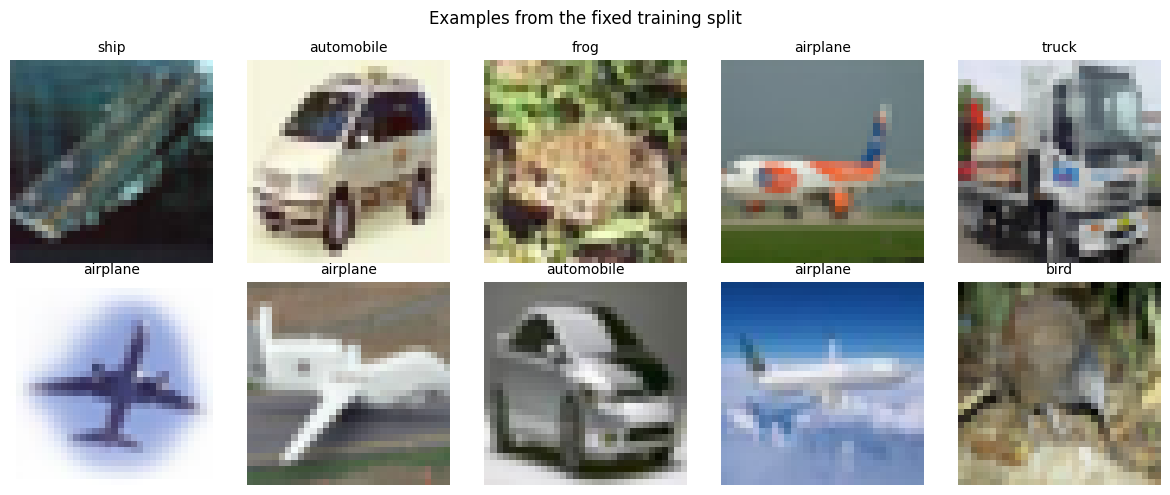

In [4]:

def show_samples(indices, nrows=2, ncols=5, title="Sample CIFAR-10 images"):
    fig = plt.figure(figsize=(12, 5))
    for i, idx in enumerate(indices[: nrows * ncols]):
        ax = plt.subplot(nrows, ncols, i + 1)
        image, label = raw_train_vis[idx]
        ax.imshow(image)
        ax.set_title(CLASS_NAMES[label], fontsize=10)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_IDX[:10], title="Examples from the fixed training split")


,train,val,test
airplane,495,98,95
automobile,537,94,117
bird,446,92,112
cat,504,100,96
deer,513,98,99
dog,485,113,96
frog,532,90,99
horse,502,108,83
ship,519,103,105
truck,467,104,98


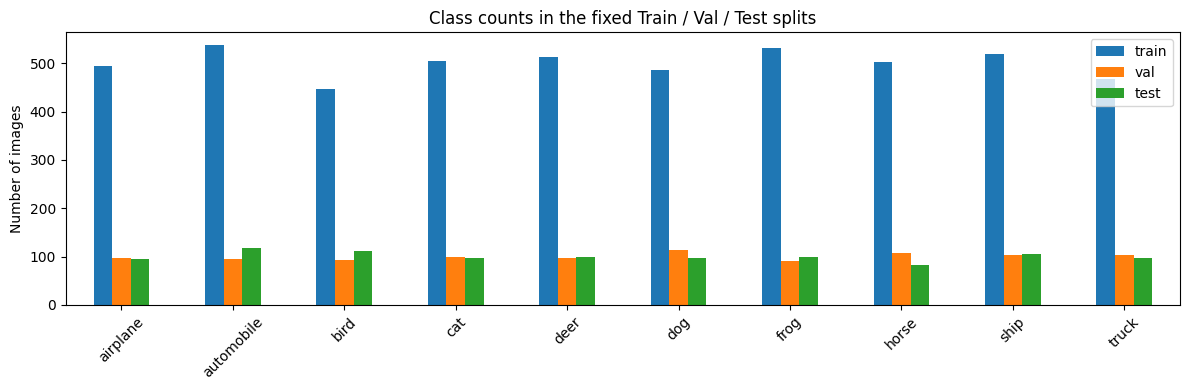

In [5]:

def count_labels(raw_dataset, indices):
    labels = [raw_dataset.targets[i] for i in indices]
    counts = pd.Series(labels).value_counts().sort_index()
    counts.index = [CLASS_NAMES[i] for i in counts.index]
    return counts

split_counts = pd.DataFrame({
    "train": count_labels(raw_train_vis, TRAIN_IDX),
    "val": count_labels(raw_train_vis, VAL_IDX),
    "test": count_labels(raw_test_vis, TEST_IDX),
})

display(split_counts)

split_counts.plot(kind="bar", figsize=(12, 4))
plt.title("Class counts in the fixed Train / Val / Test splits")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Define a small CNN

We now build a **small CNN** using the basic component including convolutional layers, batch normalization, ReLU activation, and max pooling layers. We apply the global average pooling at the end before the FC.


In [6]:

class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, use_batchnorm=False, dropout_p=0.0):
        super().__init__()
        self.use_batchnorm = use_batchnorm

        layers = []

        # Block 1
        layers.append(nn.Conv2d(3, 32, kernel_size=3, padding=1))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(32))
        layers.append(nn.ReLU(inplace=True))
        layers.append(nn.MaxPool2d(2))   # 32x32 -> 16x16

        # Block 2
        layers.append(nn.Conv2d(32, 64, kernel_size=3, padding=1))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(64))
        layers.append(nn.ReLU(inplace=True))
        layers.append(nn.MaxPool2d(2))   # 16x16 -> 8x8

        # Block 3
        layers.append(nn.Conv2d(64, 128, kernel_size=3, padding=1))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(128))
        layers.append(nn.ReLU(inplace=True))

        self.features = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

baseline_model = SmallCNN(use_batchnorm=False, dropout_p=0.0)
print(baseline_model)
print(f"Trainable parameters: {count_trainable_parameters(baseline_model):,}")


SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable parameters: 94,538


This model has:

- 3 convolutional stages
- ReLU activations
- **BatchNorm**
- **Dropout**
- global average pooling + linear classifier


## 4. Initialization helpers

In this section, we will compare:

- **zero initialization** (bad baseline)
- **Xavier initialization**
- **He / Kaiming initialization**

For convolutional and linear layers:

- **Xavier** is a common default for tanh-like activations
- **He** is usually a better match for ReLU networks


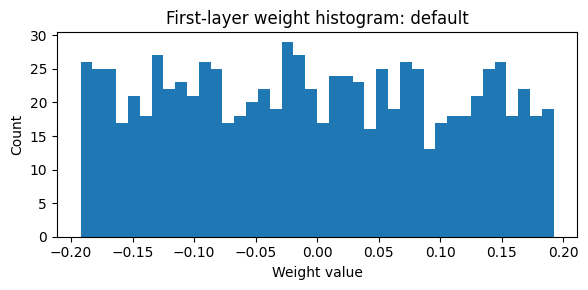

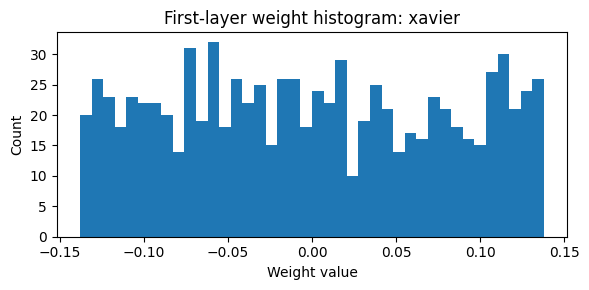

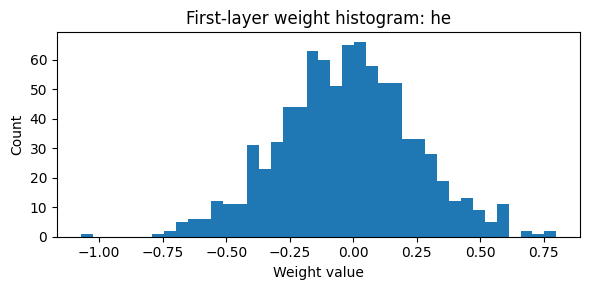

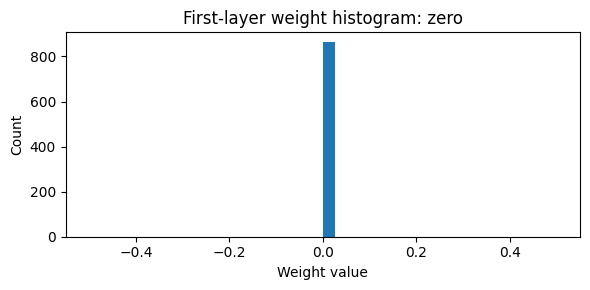

In [7]:

def initialize_model(model: nn.Module, scheme: str = "default") -> nn.Module:
    scheme = scheme.lower()

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if scheme == "default":
                # keep PyTorch defaults
                pass
            elif scheme == "zero":
                nn.init.constant_(module.weight, 0.0)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)
            elif scheme == "xavier":
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif scheme in {"he", "kaiming"}:
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            else:
                raise ValueError(f"Unknown initialization scheme: {scheme}")

        elif isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            if module.weight is not None:
                nn.init.ones_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    return model

def first_weight_array(model: nn.Module) -> np.ndarray:
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            return module.weight.detach().cpu().flatten().numpy()
    raise ValueError("Model has no Conv2d or Linear layer.")

def plot_weight_histograms(schemes=("default", "xavier", "he", "zero")):
    for scheme in schemes:
        model = SmallCNN(use_batchnorm=False, dropout_p=0.0)
        initialize_model(model, scheme)
        weights = first_weight_array(model)

        plt.figure(figsize=(6, 3))
        plt.hist(weights, bins=40)
        plt.title(f"First-layer weight histogram: {scheme}")
        plt.xlabel("Weight value")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

plot_weight_histograms()



> How do these initialization choices change the **training curves**?



## 5. Training and evaluation utilities

The next few cells include reusable helpers for:

- training one epoch
- evaluation
- early stopping
- learning-rate logging
- plotting accuracy / loss curves
- summarizing results in tables


In [8]:

def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    l1_lambda=0.0,
    max_grad_norm=None,
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, targets)

        if l1_lambda > 0.0:
            l1_penalty = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_penalty

        loss.backward()

        if max_grad_norm is not None:
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()

        batch_size = inputs.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        logits = model(inputs)
        loss = criterion(logits, targets)

        batch_size = inputs.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples

@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    all_targets = []
    all_preds = []

    for inputs, targets in loader:
        logits = model(inputs.to(device))
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.numpy().tolist())

    return np.array(all_targets), np.array(all_preds)


In [9]:

def make_optimizer(model, optimizer_name, lr, weight_decay=0.0):
    name = optimizer_name.lower()

    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    if name in {"momentum", "sgd_momentum"}:
        return torch.optim.SGD(
            model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay
        )
    if name == "nesterov":
        return torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9,
            nesterov=True,
            weight_decay=weight_decay,
        )
    if name == "adagrad":
        return torch.optim.Adagrad(model.parameters(), lr=lr, weight_decay=weight_decay)
    if name == "rmsprop":
        return torch.optim.RMSprop(
            model.parameters(), lr=lr, alpha=0.99, weight_decay=weight_decay
        )
    if name == "adam":
        return torch.optim.Adam(
            model.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=weight_decay
        )

    raise ValueError(f"Unknown optimizer: {optimizer_name}")

def make_scheduler(optimizer, scheduler_name, epochs):
    if scheduler_name is None:
        return None

    name = scheduler_name.lower()

    if name == "steplr":
        step_size = max(1, epochs // 3)
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=0.3)

    if name == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.3, patience=2
        )

    raise ValueError(f"Unsupported scheduler: {scheduler_name}")

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    device,
    scheduler=None,
    early_stopping_patience=None,
    l1_lambda=0.0,
    max_grad_norm=None,
    verbose=True,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lr": [],
        "epoch_time_sec": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -float("inf")
    best_val_loss = float("inf")
    best_epoch = 0

    wait = 0
    stopped_early = False

    for epoch in range(1, epochs + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            l1_lambda=l1_lambda,
            max_grad_norm=max_grad_norm,
        )

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        elapsed = time.time() - start
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)
        history["epoch_time_sec"].append(elapsed)

        improved = False
        if val_acc > best_val_acc + 1e-6:
            improved = True
        elif abs(val_acc - best_val_acc) <= 1e-6 and val_loss < best_val_loss:
            improved = True

        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs:02d} | "
                f"train loss={train_loss:.4f} | val loss={val_loss:.4f} | "
                f"train acc={train_acc:.4f} | val acc={val_acc:.4f} | "
                f"lr={current_lr:.5f} | time={elapsed:.1f}s"
            )

        if early_stopping_patience is not None and wait >= early_stopping_patience:
            stopped_early = True
            if verbose:
                print(
                    f"Early stopping triggered at epoch {epoch}. "
                    f"Best validation accuracy came from epoch {best_epoch}."
                )
            break

    model.load_state_dict(best_state)
    history["best_val_acc"] = best_val_acc
    history["best_val_loss"] = best_val_loss
    history["best_epoch"] = best_epoch
    history["stopped_early"] = stopped_early
    return history


In [10]:

def summarize_results(results_dict):
    rows = []
    for name, result in results_dict.items():
        history = result["history"]
        rows.append({
            "run": name,
            "best_epoch": history["best_epoch"],
            "best_val_acc": history["best_val_acc"],
            "best_val_loss": history["best_val_loss"],
            "epochs_ran": len(history["train_loss"]),
            "avg_epoch_time_sec": np.mean(history["epoch_time_sec"]),
            "batch_size": result["config"]["batch_size"],
            "optimizer": result["config"]["optimizer_name"],
            "lr": result["config"]["lr"],
            "init": result["config"]["init_scheme"],
            "batchnorm": result["config"]["use_batchnorm"],
            "dropout_p": result["config"]["dropout_p"],
            "weight_decay": result["config"]["weight_decay"],
            "train_transform": result["config"]["train_transform_name"],
        })
    df = pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
    return df

def plot_metric_comparison(results_dict, metric_key, title, ylabel):
    plt.figure(figsize=(8, 4))
    for name, result in results_dict.items():
        plt.plot(result["history"][metric_key], label=name)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_lr_curves(results_dict, title="Learning-rate schedule"):
    plt.figure(figsize=(8, 4))
    for name, result in results_dict.items():
        plt.plot(result["history"]["lr"], marker="o", label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_final_metric_bar(results_dict, metric_name="best_val_acc", title="Final validation comparison"):
    names = list(results_dict.keys())
    values = [results_dict[name]["history"][metric_name] for name in names]

    plt.figure(figsize=(8, 4))
    plt.bar(names, values)
    plt.ylabel(metric_name)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

def evaluate_and_report(model, loader, device, class_names=CLASS_NAMES):
    y_true, y_pred = collect_predictions(model, loader, device)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    display(report_df)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    print(f"Macro Precision: {macro_p:.4f}")
    print(f"Macro Recall:    {macro_r:.4f}")
    print(f"Macro F1-score:  {macro_f1:.4f}")

    return report_df


In [11]:

def run_experiment(
    name,
    *,
    batch_size=DEFAULT_BATCH_SIZE,
    epochs=None,
    init_scheme="he",
    optimizer_name="momentum",
    lr=0.01,
    scheduler_name=None,
    use_batchnorm=False,
    dropout_p=0.0,
    weight_decay=0.0,
    l1_lambda=0.0,
    early_stopping_patience=None,
    train_transform=plain_train_transform,
    train_transform_name="plain",
    eval_transform=eval_transform,
    train_idx=TRAIN_IDX,
    val_idx=VAL_IDX,
    verbose=False,
):
    if epochs is None:
        epochs = CFG["base_epochs"]

    train_loader, val_loader, _ = build_loaders(
        batch_size=batch_size,
        train_transform=train_transform,
        eval_transform=eval_transform,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=TEST_IDX,  # unused during training; kept for consistent builder signature
    )

    model = SmallCNN(
        num_classes=NUM_CLASSES,
        use_batchnorm=use_batchnorm,
        dropout_p=dropout_p,
    ).to(device)
    initialize_model(model, init_scheme)

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, optimizer_name, lr, weight_decay=weight_decay)
    scheduler = make_scheduler(optimizer, scheduler_name, epochs)

    history = fit(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=epochs,
        device=device,
        scheduler=scheduler,
        early_stopping_patience=early_stopping_patience,
        l1_lambda=l1_lambda,
        verbose=verbose,
    )

    return {
        "name": name,
        "model": model,
        "history": history,
        "config": {
            "batch_size": batch_size,
            "epochs": epochs,
            "init_scheme": init_scheme,
            "optimizer_name": optimizer_name,
            "lr": lr,
            "scheduler_name": scheduler_name,
            "use_batchnorm": use_batchnorm,
            "dropout_p": dropout_p,
            "weight_decay": weight_decay,
            "l1_lambda": l1_lambda,
            "early_stopping_patience": early_stopping_patience,
            "train_transform_name": train_transform_name,
        },
    }

def evaluate_on_test(model, batch_size=DEFAULT_BATCH_SIZE, eval_transform=eval_transform):
    _, _, test_loader = build_loaders(
        batch_size=batch_size,
        train_transform=plain_train_transform,
        eval_transform=eval_transform,
        train_idx=TRAIN_IDX,
        val_idx=VAL_IDX,
        test_idx=TEST_IDX,
    )
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")
    evaluate_and_report(model, test_loader, device)
    return test_loss, test_acc


## 6. Baseline run - how to train a CNN from scratch

We start with a simple baseline:

- **plain** training transform
- **small CNN**
- **He initialization**
- **SGD + momentum**
- fixed batch size
- short epoch budget

This gives us a reusable reference point for the rest of the notebook.


In [12]:

baseline_result = run_experiment(
    "baseline_he_momentum",
    batch_size=DEFAULT_BATCH_SIZE,
    epochs=CFG["base_epochs"],
    init_scheme="he",
    optimizer_name="momentum",
    lr=0.01,
    use_batchnorm=False,
    dropout_p=0.0,
    weight_decay=0.0,
    train_transform=plain_train_transform,
    train_transform_name="plain",
    verbose=True,
)


Epoch 01/10 | train loss=2.3930 | val loss=2.0837 | train acc=0.1884 | val acc=0.2220 | lr=0.01000 | time=1.9s
Epoch 02/10 | train loss=2.0184 | val loss=1.9901 | train acc=0.2642 | val acc=0.2640 | lr=0.01000 | time=0.9s
Epoch 03/10 | train loss=1.9048 | val loss=1.8938 | train acc=0.3076 | val acc=0.2790 | lr=0.01000 | time=0.9s
Epoch 04/10 | train loss=1.7968 | val loss=1.8269 | train acc=0.3332 | val acc=0.3260 | lr=0.01000 | time=0.9s
Epoch 05/10 | train loss=1.7148 | val loss=1.8430 | train acc=0.3652 | val acc=0.3130 | lr=0.01000 | time=1.0s
Epoch 06/10 | train loss=1.6863 | val loss=2.0589 | train acc=0.3758 | val acc=0.2920 | lr=0.01000 | time=0.9s
Epoch 07/10 | train loss=1.7397 | val loss=1.6820 | train acc=0.3558 | val acc=0.4080 | lr=0.01000 | time=0.9s
Epoch 08/10 | train loss=1.6058 | val loss=1.7083 | train acc=0.4150 | val acc=0.3860 | lr=0.01000 | time=1.0s
Epoch 09/10 | train loss=1.5769 | val loss=1.7177 | train acc=0.4254 | val acc=0.3950 | lr=0.01000 | time=1.0s
E

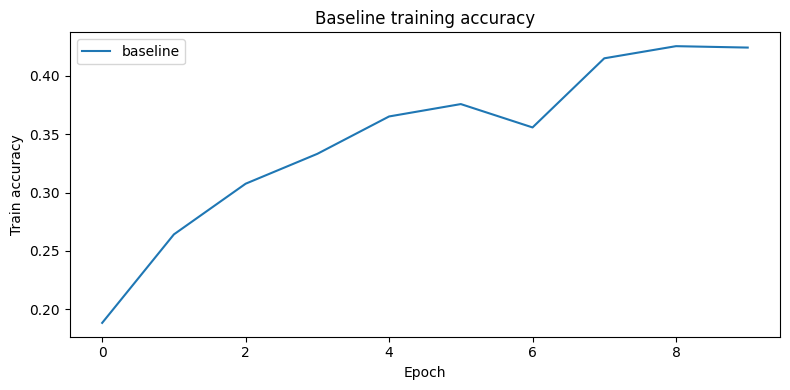

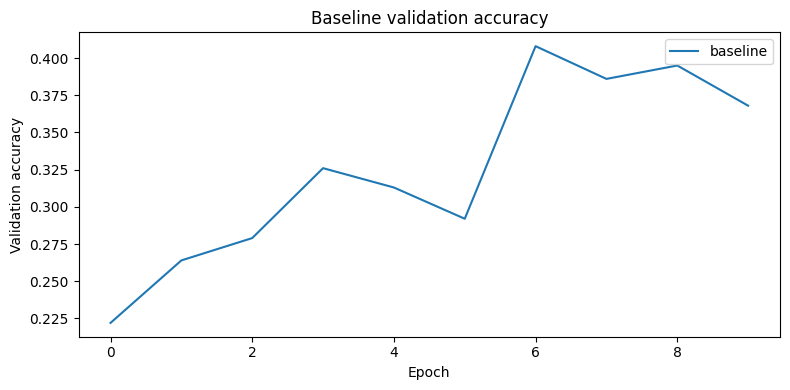

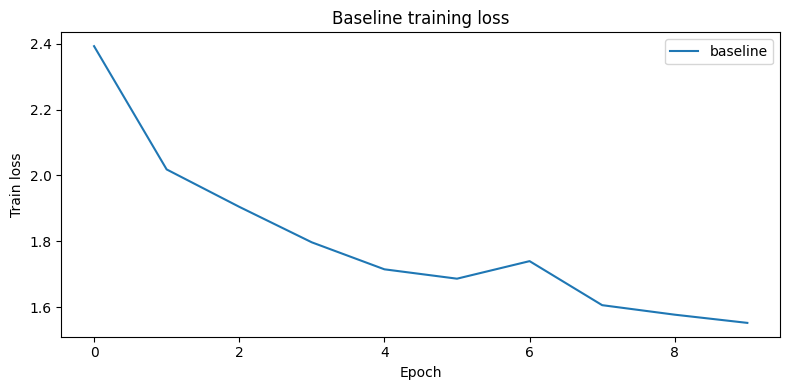

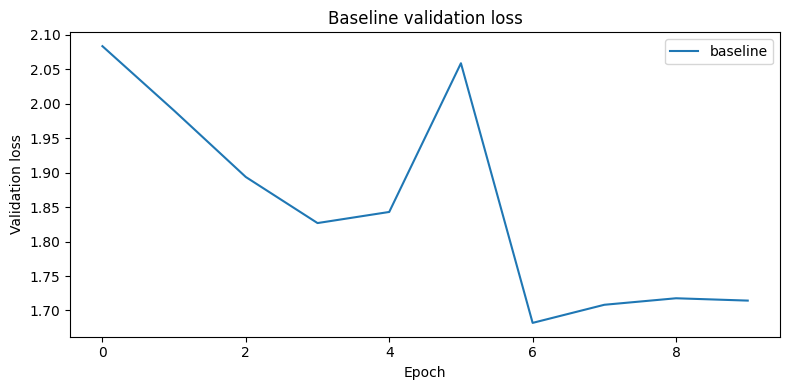

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,baseline,7,0.408,1.681982,10,1.044548,128,momentum,0.01,he,False,0.0,0.0,plain


In [13]:

plot_metric_comparison(
    {"baseline": baseline_result},
    metric_key="train_acc",
    title="Baseline training accuracy",
    ylabel="Train accuracy",
)

plot_metric_comparison(
    {"baseline": baseline_result},
    metric_key="val_acc",
    title="Baseline validation accuracy",
    ylabel="Validation accuracy",
)

plot_metric_comparison(
    {"baseline": baseline_result},
    metric_key="train_loss",
    title="Baseline training loss",
    ylabel="Train loss",
)

plot_metric_comparison(
    {"baseline": baseline_result},
    metric_key="val_loss",
    title="Baseline validation loss",
    ylabel="Validation loss",
)

display(summarize_results({"baseline": baseline_result}))



- Is the model actually learning?
- Is the gap between train and validation already large?
- Are the curves smooth or unstable?


## 7. Experiment A - Initialization matters

In this section you will compare:

- **zero**
- **Xavier**
- **He**


In [14]:

init_results = {}
for scheme in ["zero", "xavier", "he"]:
    init_results[scheme] = run_experiment(
        f"init_{scheme}",
        batch_size=DEFAULT_BATCH_SIZE,
        epochs=CFG["base_epochs"],
        init_scheme=scheme,
        optimizer_name="momentum",
        lr=0.01,
        use_batchnorm=False,
        dropout_p=0.0,
        train_transform=plain_train_transform,
        train_transform_name="plain",
        verbose=True,
    )


Epoch 01/10 | train loss=2.3024 | val loss=2.3029 | train acc=0.0972 | val acc=0.0940 | lr=0.01000 | time=0.9s
Epoch 02/10 | train loss=2.3019 | val loss=2.3029 | train acc=0.1074 | val acc=0.0940 | lr=0.01000 | time=0.9s
Epoch 03/10 | train loss=2.3015 | val loss=2.3038 | train acc=0.1074 | val acc=0.0940 | lr=0.01000 | time=1.0s
Epoch 04/10 | train loss=2.3016 | val loss=2.3042 | train acc=0.1074 | val acc=0.0940 | lr=0.01000 | time=0.9s
Epoch 05/10 | train loss=2.3015 | val loss=2.3042 | train acc=0.1074 | val acc=0.0940 | lr=0.01000 | time=0.9s
Epoch 06/10 | train loss=2.3015 | val loss=2.3043 | train acc=0.1074 | val acc=0.0940 | lr=0.01000 | time=1.0s
Epoch 07/10 | train loss=2.3014 | val loss=2.3043 | train acc=0.1074 | val acc=0.0940 | lr=0.01000 | time=1.0s
Epoch 08/10 | train loss=2.3015 | val loss=2.3042 | train acc=0.1074 | val acc=0.0940 | lr=0.01000 | time=1.0s
Epoch 09/10 | train loss=2.3013 | val loss=2.3041 | train acc=0.1074 | val acc=0.0940 | lr=0.01000 | time=1.0s
E

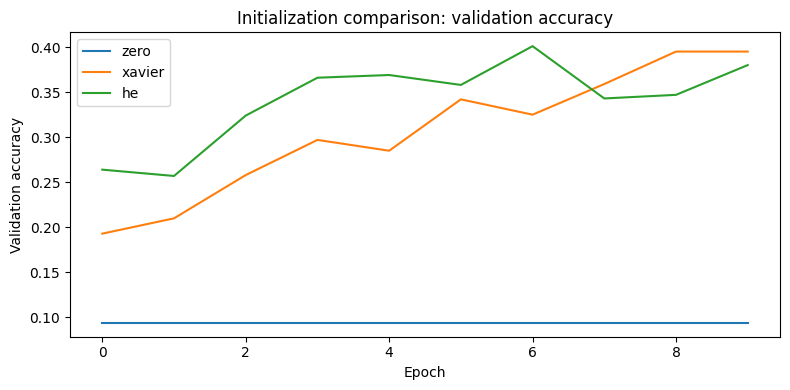

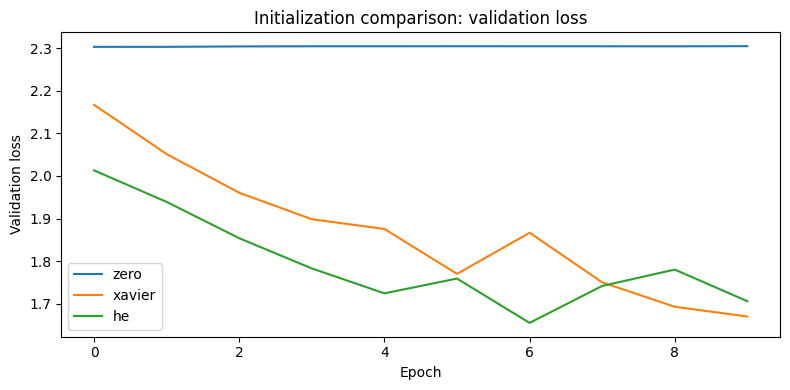

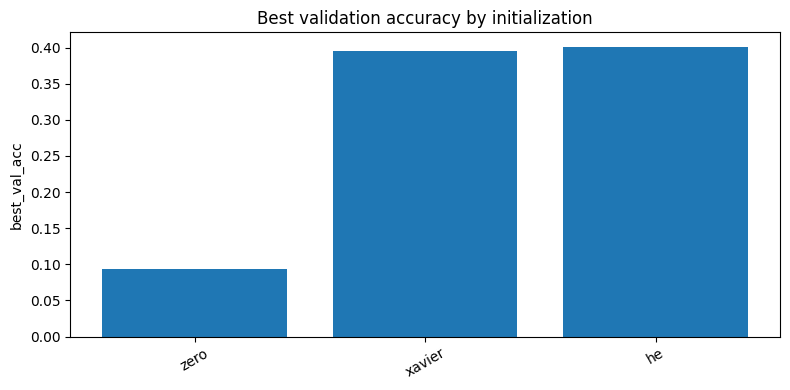

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,he,7,0.401,1.655387,10,0.970751,128,momentum,0.01,he,False,0.0,0.0,plain
1,xavier,10,0.395,1.670299,10,0.959217,128,momentum,0.01,xavier,False,0.0,0.0,plain
2,zero,1,0.094,2.302858,10,0.963288,128,momentum,0.01,zero,False,0.0,0.0,plain


In [15]:

plot_metric_comparison(init_results, "val_acc", "Initialization comparison: validation accuracy", "Validation accuracy")
plot_metric_comparison(init_results, "val_loss", "Initialization comparison: validation loss", "Validation loss")
plot_final_metric_bar(init_results, metric_name="best_val_acc", title="Best validation accuracy by initialization")
display(summarize_results(init_results))


**Based on our CNN design**:

- **zero initialization** should learn very poorly because all filters start identically
- **Xavier** should usually work better than zero
- **He** is often the best fit here because our activations are ReLU-based

If your curves do not separate much in `lab` mode, switch to `take_home` mode or run a few more epochs.


## 8. Experiment B - Batch Normalization

Here we compare:

- the same CNN **without BatchNorm**
- the same CNN **with BatchNorm**

We intentionally keep the rest of the setup fixed.


In [16]:

batchnorm_results = {}
for use_bn in [False, True]:
    run_name = "with_batchnorm" if use_bn else "without_batchnorm"
    batchnorm_results[run_name] = run_experiment(
        run_name,
        batch_size=DEFAULT_BATCH_SIZE,
        epochs=CFG["base_epochs"],
        init_scheme="he",
        optimizer_name="momentum",
        lr=0.02,
        use_batchnorm=use_bn,
        dropout_p=0.0,
        train_transform=plain_train_transform,
        train_transform_name="plain",
        verbose=True,
    )


Epoch 01/10 | train loss=2.2535 | val loss=2.0144 | train acc=0.2024 | val acc=0.2500 | lr=0.02000 | time=0.9s
Epoch 02/10 | train loss=1.9601 | val loss=2.0259 | train acc=0.2600 | val acc=0.2530 | lr=0.02000 | time=1.0s
Epoch 03/10 | train loss=1.8494 | val loss=1.7742 | train acc=0.3098 | val acc=0.3640 | lr=0.02000 | time=1.0s
Epoch 04/10 | train loss=1.7092 | val loss=2.0220 | train acc=0.3678 | val acc=0.2940 | lr=0.02000 | time=0.9s
Epoch 05/10 | train loss=1.7690 | val loss=1.7459 | train acc=0.3502 | val acc=0.3700 | lr=0.02000 | time=1.0s
Epoch 06/10 | train loss=1.6649 | val loss=1.7675 | train acc=0.3822 | val acc=0.3450 | lr=0.02000 | time=1.0s
Epoch 07/10 | train loss=1.5998 | val loss=1.6752 | train acc=0.4190 | val acc=0.3990 | lr=0.02000 | time=0.9s
Epoch 08/10 | train loss=1.5428 | val loss=1.7042 | train acc=0.4422 | val acc=0.3800 | lr=0.02000 | time=1.0s
Epoch 09/10 | train loss=1.5385 | val loss=1.5284 | train acc=0.4416 | val acc=0.4630 | lr=0.02000 | time=1.0s
E

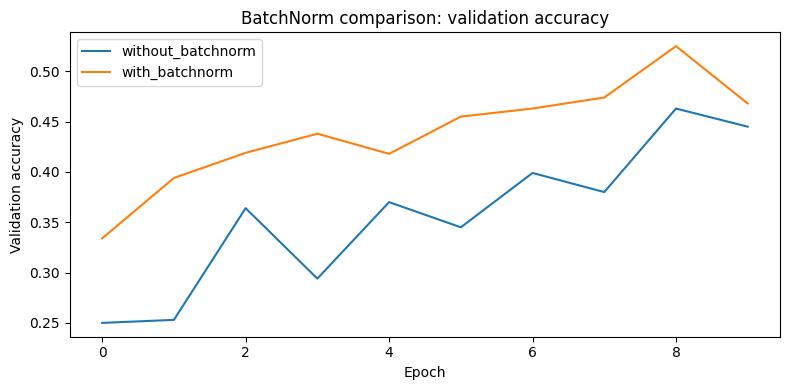

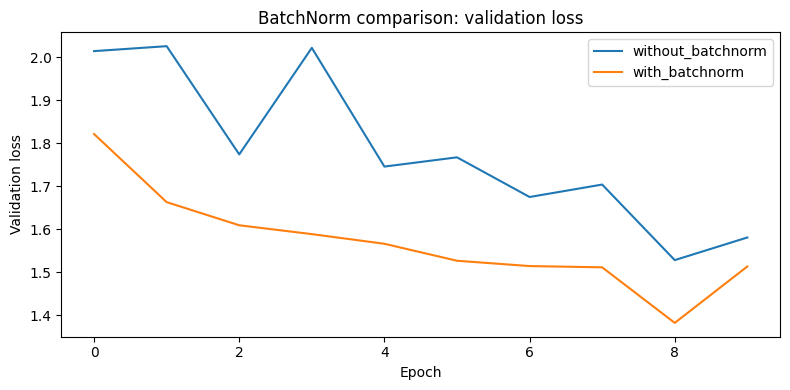

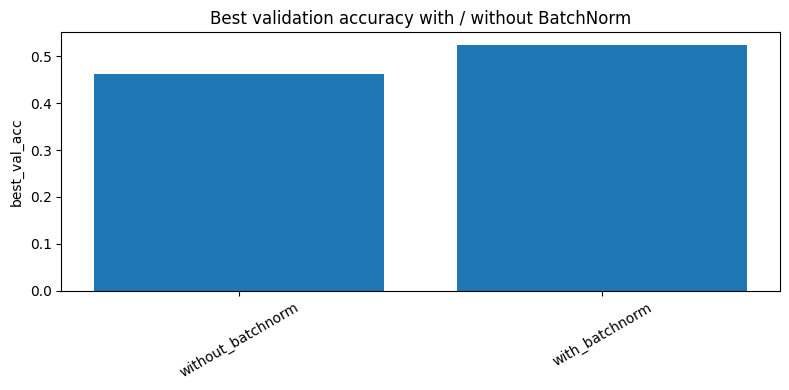

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,with_batchnorm,9,0.525,1.382499,10,0.947841,128,momentum,0.02,he,True,0.0,0.0,plain
1,without_batchnorm,9,0.463,1.528446,10,0.969839,128,momentum,0.02,he,False,0.0,0.0,plain


In [17]:

plot_metric_comparison(batchnorm_results, "val_acc", "BatchNorm comparison: validation accuracy", "Validation accuracy")
plot_metric_comparison(batchnorm_results, "val_loss", "BatchNorm comparison: validation loss", "Validation loss")
plot_final_metric_bar(batchnorm_results, metric_name="best_val_acc", title="Best validation accuracy with / without BatchNorm")
display(summarize_results(batchnorm_results))



- Does BatchNorm make the curves smoother?
- Does it tolerate a slightly larger learning rate?
- Does validation accuracy improve within the same epoch budget?



## 9. Experiment C - Batch size

We compare a few common sizes while keeping:

- architecture fixed
- initialization fixed
- optimizer fixed
- learning rate fixed
- epoch budget fixed

This is not a perfect scientific comparison, because smaller batches also produce **more updates per epoch**.  
That trade-off is part of the lesson.


In [18]:

batch_size_results = {}
for batch_size in [32, 128, 256]:
    batch_size_results[f"batch_{batch_size}"] = run_experiment(
        f"batch_{batch_size}",
        batch_size=batch_size,
        epochs=CFG["base_epochs"],
        init_scheme="he",
        optimizer_name="momentum",
        lr=0.01,
        use_batchnorm=False,
        dropout_p=0.0,
        train_transform=plain_train_transform,
        train_transform_name="plain",
        verbose=True,
    )


Epoch 01/10 | train loss=2.0626 | val loss=1.9274 | train acc=0.2490 | val acc=0.2850 | lr=0.01000 | time=1.2s
Epoch 02/10 | train loss=1.7949 | val loss=1.7265 | train acc=0.3252 | val acc=0.3720 | lr=0.01000 | time=1.1s
Epoch 03/10 | train loss=1.6795 | val loss=1.7928 | train acc=0.3798 | val acc=0.3920 | lr=0.01000 | time=1.1s
Epoch 04/10 | train loss=1.6000 | val loss=1.6109 | train acc=0.4192 | val acc=0.4440 | lr=0.01000 | time=1.1s
Epoch 05/10 | train loss=1.5327 | val loss=1.5760 | train acc=0.4420 | val acc=0.4360 | lr=0.01000 | time=1.1s
Epoch 06/10 | train loss=1.4358 | val loss=1.5198 | train acc=0.4728 | val acc=0.4580 | lr=0.01000 | time=1.2s
Epoch 07/10 | train loss=1.3874 | val loss=1.5029 | train acc=0.5060 | val acc=0.4580 | lr=0.01000 | time=1.2s
Epoch 08/10 | train loss=1.3567 | val loss=1.4937 | train acc=0.5108 | val acc=0.4610 | lr=0.01000 | time=1.2s
Epoch 09/10 | train loss=1.3131 | val loss=1.3731 | train acc=0.5262 | val acc=0.5170 | lr=0.01000 | time=1.2s
E

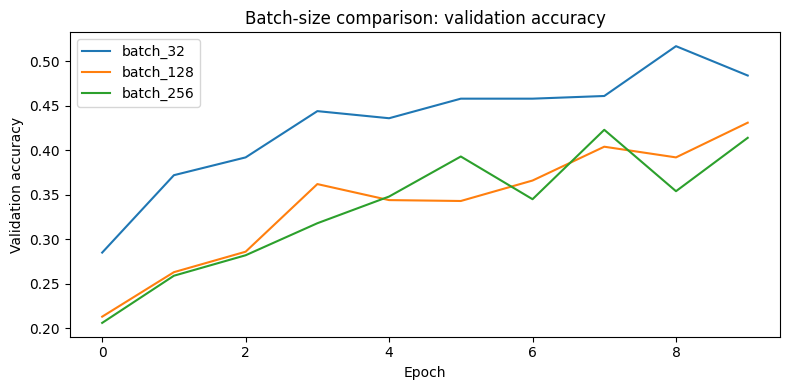

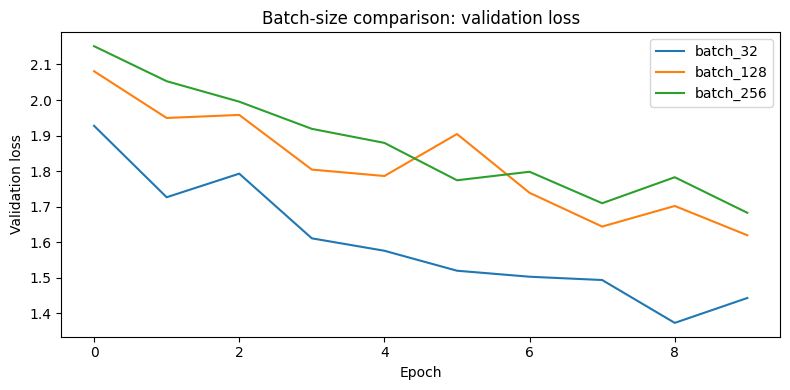

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,batch_32,9,0.517,1.373088,10,1.158755,32,momentum,0.01,he,False,0.0,0.0,plain
1,batch_128,10,0.431,1.619550,10,0.951058,128,momentum,0.01,he,False,0.0,0.0,plain
2,batch_256,8,0.423,1.709664,10,0.914195,256,momentum,0.01,he,False,0.0,0.0,plain


,run,batch_size,updates_per_epoch
0,batch_32,32,157
1,batch_128,128,40
2,batch_256,256,20


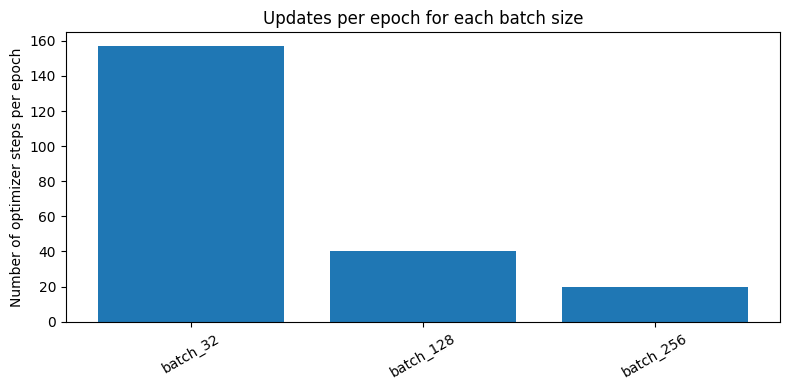

In [19]:

plot_metric_comparison(batch_size_results, "val_acc", "Batch-size comparison: validation accuracy", "Validation accuracy")
plot_metric_comparison(batch_size_results, "val_loss", "Batch-size comparison: validation loss", "Validation loss")
display(summarize_results(batch_size_results))

updates_df = summarize_results(batch_size_results)[["run", "batch_size"]].copy()
updates_df["updates_per_epoch"] = np.ceil(len(TRAIN_IDX) / updates_df["batch_size"]).astype(int)
display(updates_df)

plt.figure(figsize=(8, 4))
plt.bar(updates_df["run"], updates_df["updates_per_epoch"])
plt.title("Updates per epoch for each batch size")
plt.ylabel("Number of optimizer steps per epoch")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



- Smaller batches often give noisier but more frequent updates
- Larger batches often give smoother curves and fewer updates per epoch
- If you change batch size a lot, you may need to **re-tune the learning rate**


### batch size with scaled learning rate

Changing batch size often requires adjusting the learning rate. In this section we keep the batch sizes different, but scales the learning rate upward for larger batches.


Epoch 01/10 | train loss=2.0447 | val loss=1.8649 | train acc=0.2506 | val acc=0.2790 | lr=0.01000 | time=1.1s
Epoch 02/10 | train loss=1.7730 | val loss=1.7349 | train acc=0.3282 | val acc=0.3610 | lr=0.01000 | time=1.2s
Epoch 03/10 | train loss=1.6822 | val loss=1.7228 | train acc=0.3728 | val acc=0.3860 | lr=0.01000 | time=1.1s
Epoch 04/10 | train loss=1.5983 | val loss=1.6286 | train acc=0.4116 | val acc=0.4310 | lr=0.01000 | time=1.1s
Epoch 05/10 | train loss=1.5181 | val loss=1.6088 | train acc=0.4518 | val acc=0.4300 | lr=0.01000 | time=1.1s
Epoch 06/10 | train loss=1.4916 | val loss=1.5298 | train acc=0.4628 | val acc=0.4430 | lr=0.01000 | time=1.1s
Epoch 07/10 | train loss=1.4045 | val loss=1.4834 | train acc=0.4900 | val acc=0.4690 | lr=0.01000 | time=1.1s
Epoch 08/10 | train loss=1.3749 | val loss=1.4769 | train acc=0.4988 | val acc=0.4840 | lr=0.01000 | time=1.2s
Epoch 09/10 | train loss=1.3281 | val loss=1.5102 | train acc=0.5258 | val acc=0.4590 | lr=0.01000 | time=1.2s
E

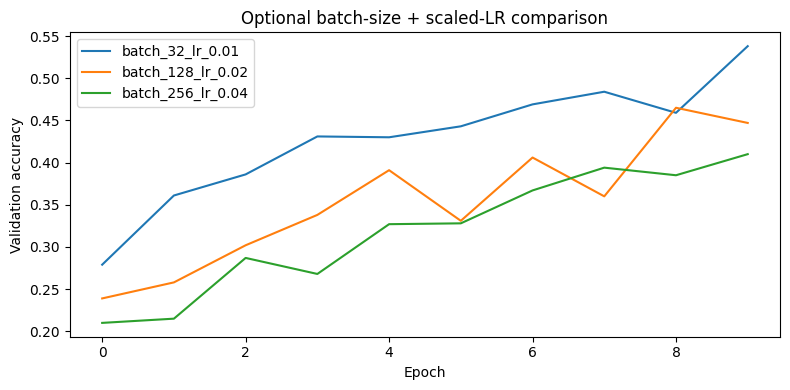

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,batch_32_lr_0.01,10,0.538,1.351982,10,1.147943,32,momentum,0.01,he,False,0.0,0.0,plain
1,batch_128_lr_0.02,9,0.465,1.543726,10,0.951216,128,momentum,0.02,he,False,0.0,0.0,plain
2,batch_256_lr_0.04,10,0.410,1.624971,10,0.942266,256,momentum,0.04,he,False,0.0,0.0,plain


In [20]:

scaled_batch_results = {}
scaled_configs = [
    (32, 0.01),
    (128, 0.02),
    (256, 0.04),
]

for batch_size, lr in scaled_configs:
    scaled_batch_results[f"batch_{batch_size}_lr_{lr}"] = run_experiment(
        f"batch_{batch_size}_lr_{lr}",
        batch_size=batch_size,
        epochs=CFG["base_epochs"],
        init_scheme="he",
        optimizer_name="momentum",
        lr=lr,
        use_batchnorm=False,
        train_transform=plain_train_transform,
        train_transform_name="plain",
        verbose=True,
    )

plot_metric_comparison(
    scaled_batch_results,
    "val_acc",
    "Optional batch-size + scaled-LR comparison",
    "Validation accuracy",
)
display(summarize_results(scaled_batch_results))


## 10. Experiment D - Optimizer comparison

Now we compare several first-order optimizers:

- **SGD**
- **Momentum**
- **Nesterov**
- **AdaGrad**
- **RMSProp**
- **Adam**



In [21]:

optimizer_configs = {
    "sgd": {"optimizer_name": "sgd", "lr": 0.01},
    "momentum": {"optimizer_name": "momentum", "lr": 0.01},
    "nesterov": {"optimizer_name": "nesterov", "lr": 0.01},
    "adagrad": {"optimizer_name": "adagrad", "lr": 0.01},
    "rmsprop": {"optimizer_name": "rmsprop", "lr": 0.001},
    "adam": {"optimizer_name": "adam", "lr": 0.001},
}

optimizer_results = {}
for name, cfg_opt in optimizer_configs.items():
    optimizer_results[name] = run_experiment(
        name,
        batch_size=DEFAULT_BATCH_SIZE,
        epochs=CFG["base_epochs"],
        init_scheme="he",
        optimizer_name=cfg_opt["optimizer_name"],
        lr=cfg_opt["lr"],
        use_batchnorm=False,
        dropout_p=0.0,
        train_transform=plain_train_transform,
        train_transform_name="plain",
        verbose=True,
    )


Epoch 01/10 | train loss=2.2542 | val loss=2.2990 | train acc=0.1818 | val acc=0.1800 | lr=0.01000 | time=0.9s
Epoch 02/10 | train loss=2.0852 | val loss=2.2095 | train acc=0.2428 | val acc=0.1970 | lr=0.01000 | time=1.0s
Epoch 03/10 | train loss=2.0274 | val loss=2.1318 | train acc=0.2524 | val acc=0.1860 | lr=0.01000 | time=0.9s
Epoch 04/10 | train loss=1.9778 | val loss=2.1771 | train acc=0.2850 | val acc=0.2080 | lr=0.01000 | time=0.9s
Epoch 05/10 | train loss=1.9486 | val loss=2.1626 | train acc=0.2888 | val acc=0.2220 | lr=0.01000 | time=1.0s
Epoch 06/10 | train loss=1.9161 | val loss=2.0968 | train acc=0.3090 | val acc=0.2590 | lr=0.01000 | time=1.0s
Epoch 07/10 | train loss=1.8903 | val loss=2.4298 | train acc=0.3134 | val acc=0.1740 | lr=0.01000 | time=1.0s
Epoch 08/10 | train loss=1.8876 | val loss=2.0933 | train acc=0.3192 | val acc=0.2260 | lr=0.01000 | time=1.0s
Epoch 09/10 | train loss=1.8509 | val loss=2.2634 | train acc=0.3356 | val acc=0.2180 | lr=0.01000 | time=1.0s
E

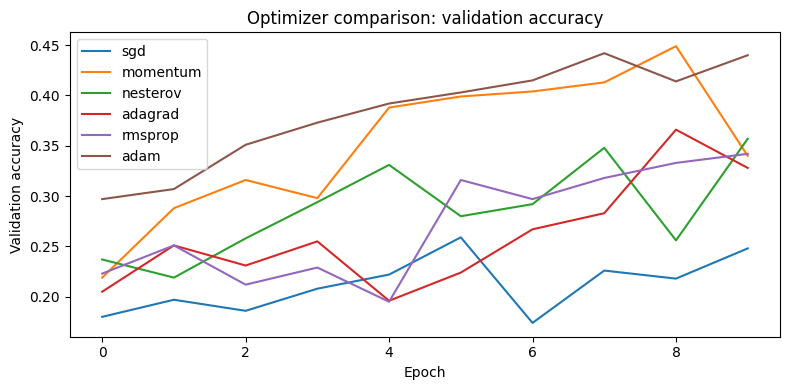

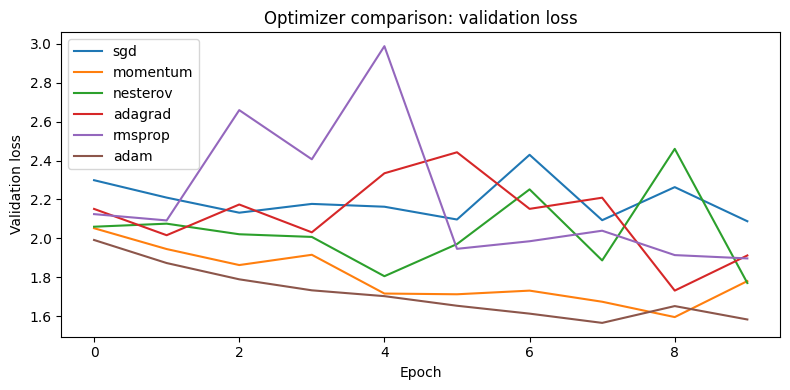

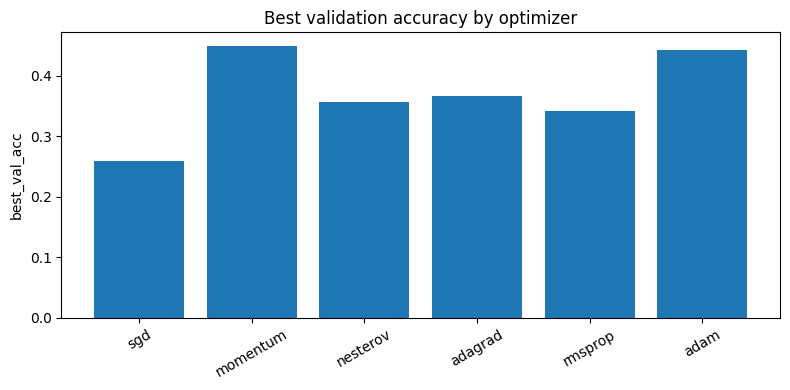

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,momentum,9,0.449,1.594703,10,0.949970,128,momentum,0.010,he,False,0.0,0.0,plain
1,adam,8,0.442,1.564831,10,0.942758,128,adam,0.001,he,False,0.0,0.0,plain
2,adagrad,9,0.366,1.731002,10,0.971284,128,adagrad,0.010,he,False,0.0,0.0,plain
3,nesterov,10,0.357,1.770019,10,0.948779,128,nesterov,0.010,he,False,0.0,0.0,plain
4,rmsprop,10,0.342,1.896602,10,0.961291,128,rmsprop,0.001,he,False,0.0,0.0,plain
5,sgd,6,0.259,2.096785,10,0.962166,128,sgd,0.010,he,False,0.0,0.0,plain


In [22]:

plot_metric_comparison(optimizer_results, "val_acc", "Optimizer comparison: validation accuracy", "Validation accuracy")
plot_metric_comparison(optimizer_results, "val_loss", "Optimizer comparison: validation loss", "Validation loss")
plot_final_metric_bar(optimizer_results, metric_name="best_val_acc", title="Best validation accuracy by optimizer")
display(summarize_results(optimizer_results))



- Which optimizer improves fastest in the first few epochs?
- Which optimizer gives the best **validation** result, not just the best training result?
- Does a faster drop in training loss always mean better generalization?

In many cases, **Adam** converges quickly, while **Momentum / Nesterov** can provide strong and stable baselines.


## 11. Experiment E - Learning rate

Usually, the learning rate is often the **first thing to debug**:

- too high → unstable or oscillating
- too low → very slow progress
- reasonable → steady improvement

To make this easier to see, we use **plain SGD** here.


In [23]:

lr_results = {}
for lr in [0.1, 0.01, 0.001]:
    lr_results[f"lr_{lr}"] = run_experiment(
        f"lr_{lr}",
        batch_size=DEFAULT_BATCH_SIZE,
        epochs=CFG["base_epochs"],
        init_scheme="he",
        optimizer_name="sgd",
        lr=lr,
        use_batchnorm=False,
        dropout_p=0.0,
        train_transform=plain_train_transform,
        train_transform_name="plain",
        verbose=True,
    )


Epoch 01/10 | train loss=2.4010 | val loss=2.3955 | train acc=0.1894 | val acc=0.1420 | lr=0.10000 | time=0.9s
Epoch 02/10 | train loss=2.0215 | val loss=2.2250 | train acc=0.2538 | val acc=0.2270 | lr=0.10000 | time=0.9s
Epoch 03/10 | train loss=1.9490 | val loss=2.2975 | train acc=0.2818 | val acc=0.2290 | lr=0.10000 | time=1.0s
Epoch 04/10 | train loss=1.8935 | val loss=2.1847 | train acc=0.2958 | val acc=0.2040 | lr=0.10000 | time=1.0s
Epoch 05/10 | train loss=1.8413 | val loss=2.8916 | train acc=0.3260 | val acc=0.1900 | lr=0.10000 | time=1.0s
Epoch 06/10 | train loss=1.8431 | val loss=2.2010 | train acc=0.3302 | val acc=0.2560 | lr=0.10000 | time=0.9s
Epoch 07/10 | train loss=1.7706 | val loss=1.8244 | train acc=0.3554 | val acc=0.3210 | lr=0.10000 | time=0.9s
Epoch 08/10 | train loss=1.7230 | val loss=3.0703 | train acc=0.3642 | val acc=0.1670 | lr=0.10000 | time=1.0s
Epoch 09/10 | train loss=1.7573 | val loss=1.9005 | train acc=0.3630 | val acc=0.2800 | lr=0.10000 | time=0.9s
E

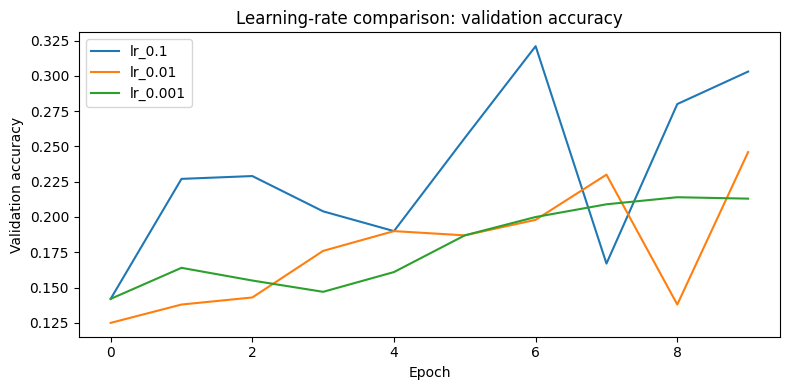

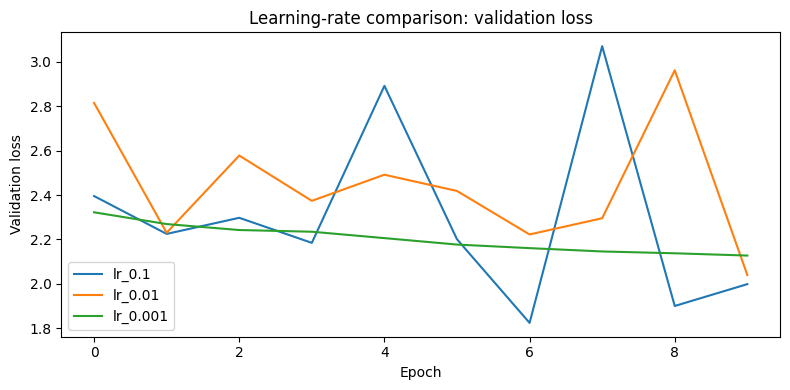

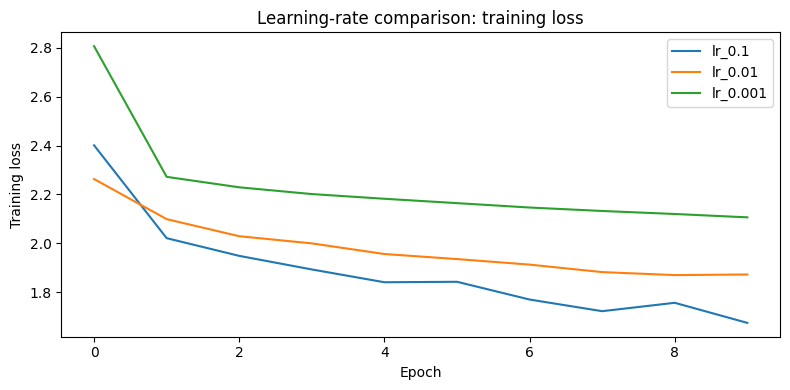

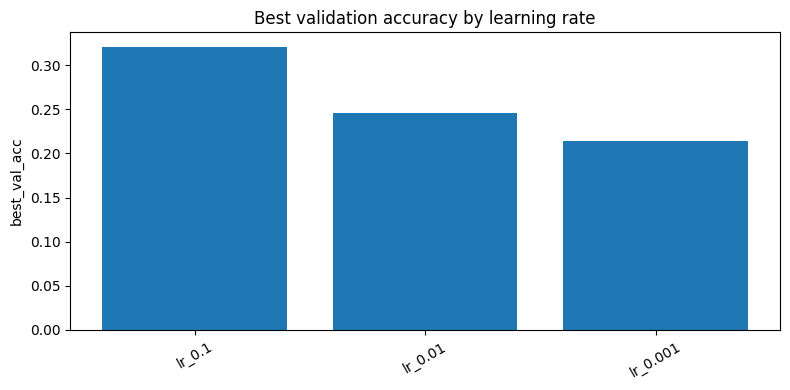

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,lr_0.1,7,0.321,1.824376,10,0.954599,128,sgd,0.100,he,False,0.0,0.0,plain
1,lr_0.01,10,0.246,2.039784,10,0.952065,128,sgd,0.010,he,False,0.0,0.0,plain
2,lr_0.001,9,0.214,2.137743,10,0.950984,128,sgd,0.001,he,False,0.0,0.0,plain


In [24]:

plot_metric_comparison(lr_results, "val_acc", "Learning-rate comparison: validation accuracy", "Validation accuracy")
plot_metric_comparison(lr_results, "val_loss", "Learning-rate comparison: validation loss", "Validation loss")
plot_metric_comparison(lr_results, "train_loss", "Learning-rate comparison: training loss", "Training loss")
plot_final_metric_bar(lr_results, metric_name="best_val_acc", title="Best validation accuracy by learning rate")
display(summarize_results(lr_results))



- Does the highest learning rate oscillate or diverge?
- Does the smallest learning rate move too slowly?
- Which setting gives the best balance between speed and stability?

If `0.1` happens to be stable in your environment, increase the largest candidate slightly or extend the epoch budget to make the contrast clearer.


## 12. Experiment F - Learning-rate schedules

Here we compare:

- **constant learning rate**
- **StepLR**


In [25]:

scheduler_results = {
    "constant_lr": run_experiment(
        "constant_lr",
        batch_size=DEFAULT_BATCH_SIZE,
        epochs=CFG["long_epochs"],
        init_scheme="he",
        optimizer_name="momentum",
        lr=0.02,
        scheduler_name=None,
        use_batchnorm=False,
        train_transform=plain_train_transform,
        train_transform_name="plain",
        verbose=True,
    ),
    "step_lr": run_experiment(
        "step_lr",
        batch_size=DEFAULT_BATCH_SIZE,
        epochs=CFG["long_epochs"],
        init_scheme="he",
        optimizer_name="momentum",
        lr=0.02,
        scheduler_name="steplr",
        use_batchnorm=False,
        train_transform=plain_train_transform,
        train_transform_name="plain",
        verbose=True,
    ),
}


Epoch 01/20 | train loss=2.3695 | val loss=2.0565 | train acc=0.1834 | val acc=0.2570 | lr=0.02000 | time=1.0s
Epoch 02/20 | train loss=1.9747 | val loss=2.0106 | train acc=0.2476 | val acc=0.2320 | lr=0.02000 | time=1.0s
Epoch 03/20 | train loss=1.8676 | val loss=1.7632 | train acc=0.3058 | val acc=0.3660 | lr=0.02000 | time=1.0s
Epoch 04/20 | train loss=1.7176 | val loss=1.7140 | train acc=0.3598 | val acc=0.3570 | lr=0.02000 | time=0.9s
Epoch 05/20 | train loss=1.6739 | val loss=1.9333 | train acc=0.3800 | val acc=0.3000 | lr=0.02000 | time=1.0s
Epoch 06/20 | train loss=1.6931 | val loss=1.6970 | train acc=0.3720 | val acc=0.3900 | lr=0.02000 | time=1.0s
Epoch 07/20 | train loss=1.5829 | val loss=1.6642 | train acc=0.4182 | val acc=0.3980 | lr=0.02000 | time=1.0s
Epoch 08/20 | train loss=1.5818 | val loss=1.7467 | train acc=0.4128 | val acc=0.3610 | lr=0.02000 | time=1.0s
Epoch 09/20 | train loss=1.5269 | val loss=1.6467 | train acc=0.4376 | val acc=0.4200 | lr=0.02000 | time=0.9s
E

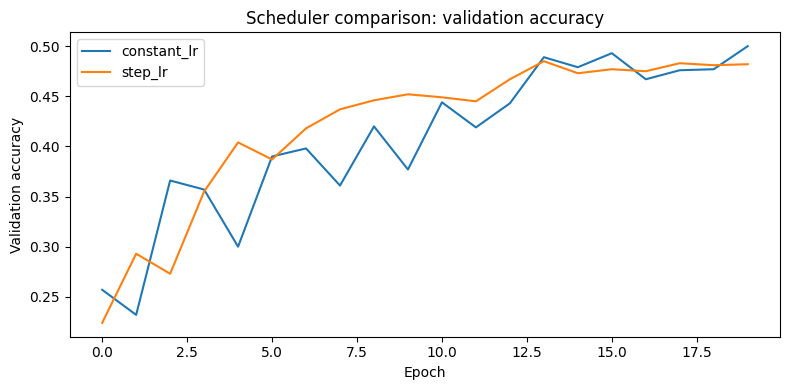

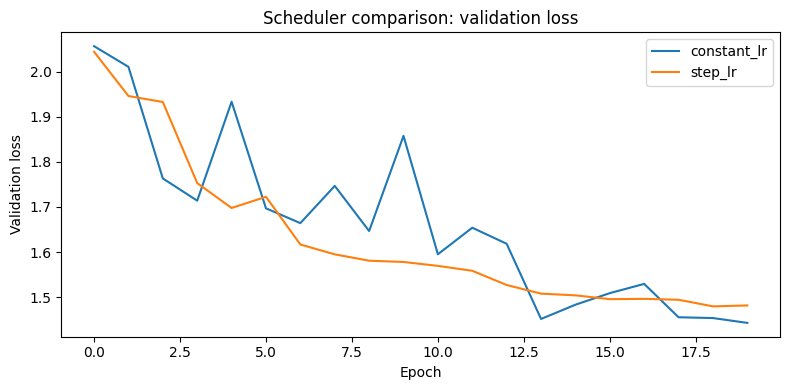

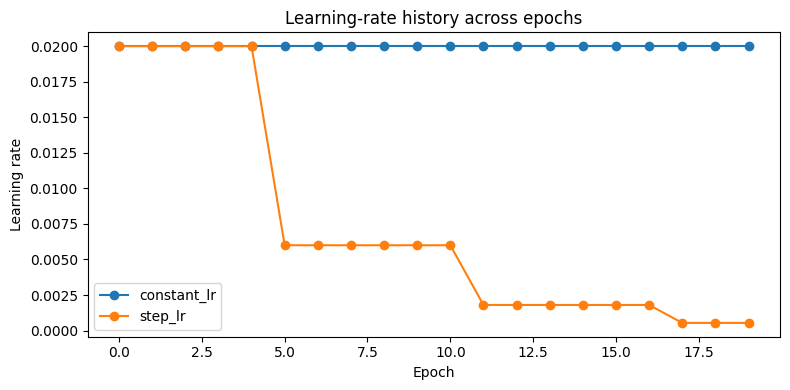

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,constant_lr,20,0.500,1.443055,20,0.972474,128,momentum,0.02,he,False,0.0,0.0,plain
1,step_lr,14,0.485,1.507866,20,0.962958,128,momentum,0.02,he,False,0.0,0.0,plain


In [26]:

plot_metric_comparison(scheduler_results, "val_acc", "Scheduler comparison: validation accuracy", "Validation accuracy")
plot_metric_comparison(scheduler_results, "val_loss", "Scheduler comparison: validation loss", "Validation loss")
plot_lr_curves(scheduler_results, title="Learning-rate history across epochs")
display(summarize_results(scheduler_results))


### Visualize a cyclic schedule

This cell does **not** train a model. It simply shows how the learning rate would move under a **CyclicLR** scheduler.


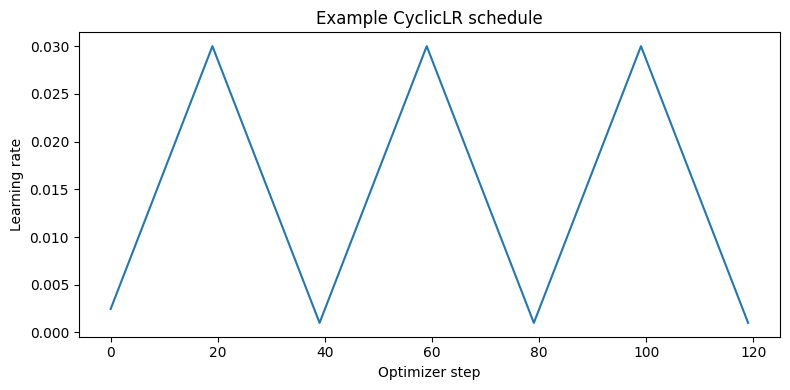

In [27]:

dummy_model = SmallCNN()
dummy_optimizer = torch.optim.SGD(dummy_model.parameters(), lr=1e-3, momentum=0.9)
cyclic_scheduler = torch.optim.lr_scheduler.CyclicLR(
    dummy_optimizer,
    base_lr=1e-3,
    max_lr=3e-2,
    step_size_up=20,
    cycle_momentum=False,
)

cyclic_lrs = []
for _ in range(120):
    dummy_optimizer.step()
    cyclic_scheduler.step()
    cyclic_lrs.append(dummy_optimizer.param_groups[0]["lr"])

plt.figure(figsize=(8, 4))
plt.plot(cyclic_lrs)
plt.title("Example CyclicLR schedule")
plt.xlabel("Optimizer step")
plt.ylabel("Learning rate")
plt.tight_layout()
plt.show()



- Does StepLR help the model settle later in training?
- Does the learning-rate history match the schedule you expected?
- How is a cyclic policy visually different from a decaying policy?


## 13. Experiment G - Regularization and early stopping

There are several ways to improve generalization:

- **L2 regularization / weight decay**
- **dropout**
- **data augmentation**
- **early stopping**

We will compare a few practical combinations.

> In `lab` mode, regularization effects may be subtle.  
> In `take_home` mode, or with more epochs, the separation is usually clearer.


In [28]:

regularization_results = {
    "plain_no_reg": run_experiment(
        "plain_no_reg",
        batch_size=DEFAULT_BATCH_SIZE,
        epochs=CFG["reg_epochs"],
        init_scheme="he",
        optimizer_name="momentum",
        lr=0.01,
        use_batchnorm=False,
        dropout_p=0.0,
        weight_decay=0.0,
        train_transform=plain_train_transform,
        train_transform_name="plain",
        verbose=True,
    ),
    "plain_weight_decay": run_experiment(
        "plain_weight_decay",
        batch_size=DEFAULT_BATCH_SIZE,
        epochs=CFG["reg_epochs"],
        init_scheme="he",
        optimizer_name="momentum",
        lr=0.01,
        use_batchnorm=False,
        dropout_p=0.0,
        weight_decay=1e-4,
        train_transform=plain_train_transform,
        train_transform_name="plain",
        verbose=True,
    ),
    "aug_dropout_weight_decay": run_experiment(
        "aug_dropout_weight_decay",
        batch_size=DEFAULT_BATCH_SIZE,
        epochs=CFG["reg_epochs"],
        init_scheme="he",
        optimizer_name="momentum",
        lr=0.01,
        use_batchnorm=False,
        dropout_p=0.3,
        weight_decay=1e-4,
        train_transform=aug_train_transform,
        train_transform_name="augmented",
        verbose=True,
    ),
}


Epoch 01/15 | train loss=2.2527 | val loss=2.0442 | train acc=0.1960 | val acc=0.2150 | lr=0.01000 | time=1.0s
Epoch 02/15 | train loss=1.9729 | val loss=1.9063 | train acc=0.2722 | val acc=0.3020 | lr=0.01000 | time=0.9s
Epoch 03/15 | train loss=1.8395 | val loss=1.8465 | train acc=0.3324 | val acc=0.2920 | lr=0.01000 | time=1.0s
Epoch 04/15 | train loss=1.7485 | val loss=1.7827 | train acc=0.3596 | val acc=0.3220 | lr=0.01000 | time=1.0s
Epoch 05/15 | train loss=1.6917 | val loss=1.7348 | train acc=0.3754 | val acc=0.3760 | lr=0.01000 | time=1.0s
Epoch 06/15 | train loss=1.6737 | val loss=1.8171 | train acc=0.3792 | val acc=0.3610 | lr=0.01000 | time=1.0s
Epoch 07/15 | train loss=1.6347 | val loss=1.6520 | train acc=0.4108 | val acc=0.4110 | lr=0.01000 | time=0.9s
Epoch 08/15 | train loss=1.5686 | val loss=1.6302 | train acc=0.4354 | val acc=0.4110 | lr=0.01000 | time=0.9s
Epoch 09/15 | train loss=1.5342 | val loss=1.7161 | train acc=0.4406 | val acc=0.3900 | lr=0.01000 | time=1.0s
E

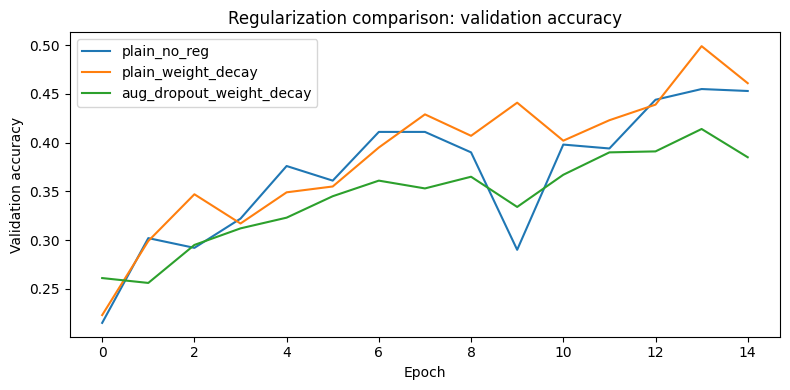

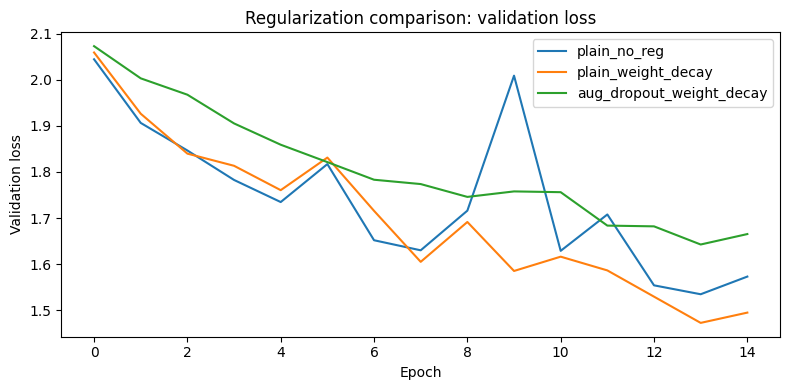

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,plain_weight_decay,14,0.499,1.472890,15,0.966031,128,momentum,0.01,he,False,0.0,0.0001,plain
1,plain_no_reg,14,0.455,1.534952,15,0.953257,128,momentum,0.01,he,False,0.0,0.0000,plain
2,aug_dropout_weight_decay,14,0.414,1.642763,15,1.312004,128,momentum,0.01,he,False,0.3,0.0001,augmented


In [29]:

plot_metric_comparison(regularization_results, "val_acc", "Regularization comparison: validation accuracy", "Validation accuracy")
plot_metric_comparison(regularization_results, "val_loss", "Regularization comparison: validation loss", "Validation loss")
display(summarize_results(regularization_results))


### L1 regularization

In practice, **L2 / weight decay** is much more common in deep learning.  
Still, here is a short L1 example you can try.


In [30]:

l1_result = run_experiment(
    "l1_demo",
    batch_size=DEFAULT_BATCH_SIZE,
    epochs=CFG["base_epochs"],
    init_scheme="he",
    optimizer_name="momentum",
    lr=0.01,
    use_batchnorm=False,
    dropout_p=0.0,
    l1_lambda=1e-7,
    train_transform=plain_train_transform,
    train_transform_name="plain",
    verbose=True,
)

display(summarize_results({"l1_demo": l1_result}))


Epoch 01/10 | train loss=2.2002 | val loss=2.0553 | train acc=0.2042 | val acc=0.2730 | lr=0.01000 | time=1.0s
Epoch 02/10 | train loss=1.9567 | val loss=1.8832 | train acc=0.2924 | val acc=0.3200 | lr=0.01000 | time=0.9s
Epoch 03/10 | train loss=1.8304 | val loss=1.7869 | train acc=0.3318 | val acc=0.3460 | lr=0.01000 | time=1.0s
Epoch 04/10 | train loss=1.7519 | val loss=1.7844 | train acc=0.3566 | val acc=0.3500 | lr=0.01000 | time=1.0s
Epoch 05/10 | train loss=1.7028 | val loss=1.7329 | train acc=0.3700 | val acc=0.3790 | lr=0.01000 | time=0.9s
Epoch 06/10 | train loss=1.6554 | val loss=1.8578 | train acc=0.3936 | val acc=0.3340 | lr=0.01000 | time=1.0s
Epoch 07/10 | train loss=1.6594 | val loss=1.6316 | train acc=0.3870 | val acc=0.4200 | lr=0.01000 | time=1.0s
Epoch 08/10 | train loss=1.5797 | val loss=1.6342 | train acc=0.4216 | val acc=0.4210 | lr=0.01000 | time=0.9s
Epoch 09/10 | train loss=1.5670 | val loss=1.6371 | train acc=0.4258 | val acc=0.4050 | lr=0.01000 | time=1.0s
E

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,l1_demo,8,0.421,1.634215,10,0.96703,128,momentum,0.01,he,False,0.0,0.0,plain


### Early stopping demo

This run uses a larger epoch budget but stops if the validation score stops improving for a few epochs.


In [31]:

early_stopping_result = run_experiment(
    "early_stopping_demo",
    batch_size=DEFAULT_BATCH_SIZE,
    epochs=max(CFG["long_epochs"], 50),
    init_scheme="he",
    optimizer_name="momentum",
    lr=0.01,
    use_batchnorm=False,
    dropout_p=0.3,
    weight_decay=1e-4,
    early_stopping_patience=3,
    train_transform=aug_train_transform,
    train_transform_name="augmented",
    verbose=True,
)


Epoch 01/50 | train loss=2.4853 | val loss=2.1235 | train acc=0.1502 | val acc=0.1950 | lr=0.01000 | time=1.3s
Epoch 02/50 | train loss=2.0915 | val loss=2.0270 | train acc=0.2074 | val acc=0.2620 | lr=0.01000 | time=1.4s
Epoch 03/50 | train loss=2.0277 | val loss=1.9880 | train acc=0.2346 | val acc=0.2450 | lr=0.01000 | time=1.3s
Epoch 04/50 | train loss=1.9689 | val loss=1.9319 | train acc=0.2674 | val acc=0.2580 | lr=0.01000 | time=1.3s
Epoch 05/50 | train loss=1.9251 | val loss=1.9118 | train acc=0.2800 | val acc=0.2780 | lr=0.01000 | time=1.3s
Epoch 06/50 | train loss=1.8924 | val loss=1.8635 | train acc=0.2810 | val acc=0.3050 | lr=0.01000 | time=1.4s
Epoch 07/50 | train loss=1.8399 | val loss=1.7924 | train acc=0.3046 | val acc=0.3250 | lr=0.01000 | time=1.3s
Epoch 08/50 | train loss=1.8124 | val loss=1.7945 | train acc=0.3162 | val acc=0.3390 | lr=0.01000 | time=1.4s
Epoch 09/50 | train loss=1.7957 | val loss=1.8209 | train acc=0.3226 | val acc=0.3500 | lr=0.01000 | time=1.4s
E

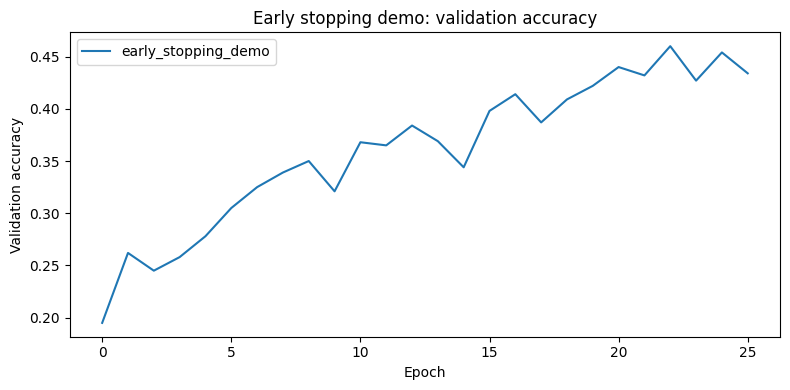

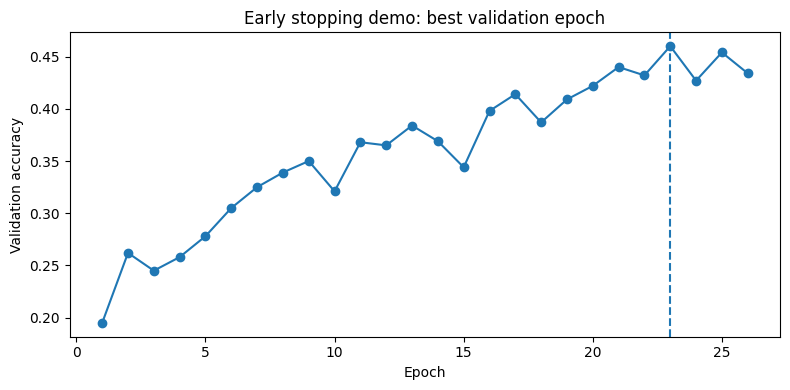

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,early_stopping_demo,23,0.46,1.576244,26,1.344466,128,momentum,0.01,he,False,0.3,0.0001,augmented


In [32]:

plot_metric_comparison(
    {"early_stopping_demo": early_stopping_result},
    "val_acc",
    "Early stopping demo: validation accuracy",
    "Validation accuracy",
)

plt.figure(figsize=(8, 4))
history = early_stopping_result["history"]
epochs = np.arange(1, len(history["val_acc"]) + 1)
plt.plot(epochs, history["val_acc"], marker="o")
plt.axvline(history["best_epoch"], linestyle="--")
plt.title("Early stopping demo: best validation epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.tight_layout()
plt.show()

display(summarize_results({"early_stopping_demo": early_stopping_result}))



- Does weight decay improve validation behavior?
- Does dropout + augmentation reduce overfitting?
- Does early stopping recover a better checkpoint than simply taking the final epoch?


## 14. Hyperparameter tuning

We introduce two complementary ideas:

1. **one-factor-at-a-time** sweeps for understanding  
2. **random search** when you want to explore several hyperparameters jointly


### Step 1 - summarize what we already learned from the earlier sweeps


In [33]:

ablation_summary = pd.concat(
    [
        summarize_results(init_results).assign(section="initialization"),
        summarize_results(batchnorm_results).assign(section="batchnorm"),
        summarize_results(batch_size_results).assign(section="batch_size"),
        summarize_results(optimizer_results).assign(section="optimizer"),
        summarize_results(lr_results).assign(section="learning_rate"),
        summarize_results(scheduler_results).assign(section="scheduler"),
        summarize_results(regularization_results).assign(section="regularization"),
    ],
    ignore_index=True,
)

display(ablation_summary.sort_values("best_val_acc", ascending=False).head(15))


,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform,section
3,with_batchnorm,9,0.525,1.382499,10,0.947841,128,momentum,0.020,he,True,0.0,0.0000,plain,batchnorm
5,batch_32,9,0.517,1.373088,10,1.158755,32,momentum,0.010,he,False,0.0,0.0000,plain,batch_size
17,constant_lr,20,0.500,1.443055,20,0.972474,128,momentum,0.020,he,False,0.0,0.0000,plain,scheduler
19,plain_weight_decay,14,0.499,1.472890,15,0.966031,128,momentum,0.010,he,False,0.0,0.0001,plain,regularization
18,step_lr,14,0.485,1.507866,20,0.962958,128,momentum,0.020,he,False,0.0,0.0000,plain,scheduler
4,without_batchnorm,9,0.463,1.528446,10,0.969839,128,momentum,0.020,he,False,0.0,0.0000,plain,batchnorm
20,plain_no_reg,14,0.455,1.534952,15,0.953257,128,momentum,0.010,he,False,0.0,0.0000,plain,regularization
8,momentum,9,0.449,1.594703,10,0.949970,128,momentum,0.010,he,False,0.0,0.0000,plain,optimizer
9,adam,8,0.442,1.564831,10,0.942758,128,adam,0.001,he,False,0.0,0.0000,plain,optimizer
6,batch_128,10,0.431,1.619550,10,0.951058,128,momentum,0.010,he,False,0.0,0.0000,plain,batch_size


### Step 2 - a small random search

We tune on a smaller subset and a short epoch budget.
We search jointly over:

- learning rate
- weight decay
- batch size
- dropout probability


In [34]:

TUNING_TRAIN_IDX = TRAIN_IDX[: min(len(TRAIN_IDX), 3000)]
TUNING_VAL_IDX = VAL_IDX[: min(len(VAL_IDX), 1000)]

def sample_log_uniform(low, high):
    return 10 ** np.random.uniform(np.log10(low), np.log10(high))

def run_random_search(n_trials=None, verbose=True):
    if n_trials is None:
        n_trials = CFG["tuning_trials"] if RUN_FULL_HPARAM_SEARCH else max(3, CFG["tuning_trials"] - 1)

    search_results = []

    for trial in range(1, n_trials + 1):
        lr = sample_log_uniform(1e-4, 5e-2)
        weight_decay = sample_log_uniform(1e-6, 1e-3)
        batch_size = int(np.random.choice([64, 128, 256]))
        dropout_p = float(np.random.choice([0.0, 0.2, 0.3]))

        result = run_experiment(
            f"trial_{trial}",
            batch_size=batch_size,
            epochs=max(3, CFG["base_epochs"] - 1),
            init_scheme="he",
            optimizer_name="momentum",
            lr=lr,
            use_batchnorm=True,
            dropout_p=dropout_p,
            weight_decay=weight_decay,
            train_transform=aug_train_transform,
            train_transform_name="augmented",
            train_idx=TUNING_TRAIN_IDX,
            val_idx=TUNING_VAL_IDX,
            verbose=verbose,
        )

        row = {
            "trial": trial,
            "lr": lr,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "dropout_p": dropout_p,
            "best_val_acc": result["history"]["best_val_acc"],
            "best_val_loss": result["history"]["best_val_loss"],
            "best_epoch": result["history"]["best_epoch"],
            "result_obj": result,
        }
        search_results.append(row)

    df = pd.DataFrame(search_results).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
    return df

random_search_df = run_random_search(verbose=True)
display(random_search_df.drop(columns=["result_obj"]))


Epoch 01/09 | train loss=2.2739 | val loss=2.1342 | train acc=0.1593 | val acc=0.2040 | lr=0.00542 | time=0.9s
Epoch 02/09 | train loss=2.0454 | val loss=1.9987 | train acc=0.2480 | val acc=0.2600 | lr=0.00542 | time=1.0s
Epoch 03/09 | train loss=1.9513 | val loss=1.9464 | train acc=0.2990 | val acc=0.2770 | lr=0.00542 | time=0.9s
Epoch 04/09 | train loss=1.9044 | val loss=1.9017 | train acc=0.3017 | val acc=0.2920 | lr=0.00542 | time=0.9s
Epoch 05/09 | train loss=1.8676 | val loss=1.8778 | train acc=0.3237 | val acc=0.3120 | lr=0.00542 | time=0.9s
Epoch 06/09 | train loss=1.8366 | val loss=1.8541 | train acc=0.3320 | val acc=0.3110 | lr=0.00542 | time=1.0s
Epoch 07/09 | train loss=1.8174 | val loss=1.8456 | train acc=0.3397 | val acc=0.3220 | lr=0.00542 | time=0.9s
Epoch 08/09 | train loss=1.7914 | val loss=1.8281 | train acc=0.3640 | val acc=0.3340 | lr=0.00542 | time=1.0s
Epoch 09/09 | train loss=1.7721 | val loss=1.8095 | train acc=0.3630 | val acc=0.3410 | lr=0.00542 | time=1.0s
E

,trial,lr,weight_decay,batch_size,dropout_p,best_val_acc,best_val_loss,best_epoch
0,7,0.031469,0.000045,64,0.3,0.457,1.533746,9
1,3,0.037149,0.000168,128,0.2,0.427,1.619213,8
2,8,0.003264,0.000016,64,0.0,0.360,1.739857,9
3,4,0.013442,0.000002,256,0.3,0.356,1.769958,9
4,1,0.005416,0.000276,128,0.0,0.341,1.809529,9
5,2,0.004743,0.000002,128,0.0,0.336,1.796393,9
6,5,0.000342,0.001000,64,0.3,0.239,2.039980,9
7,6,0.000396,0.000010,128,0.0,0.211,2.131959,9


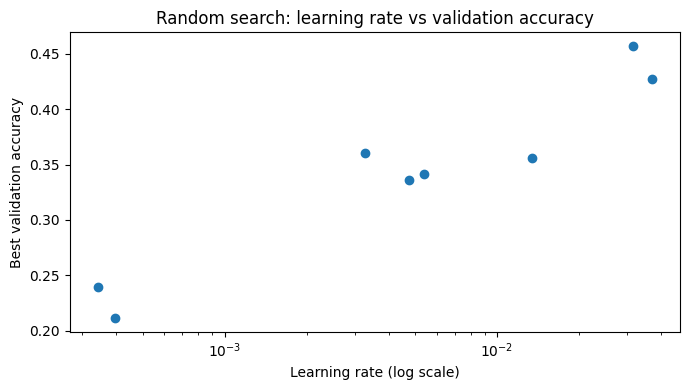

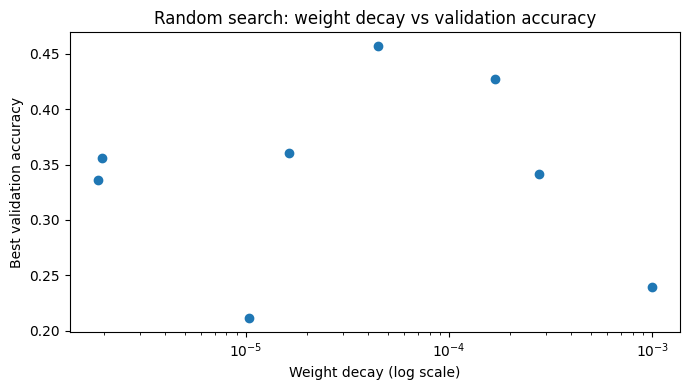

In [35]:

plt.figure(figsize=(7, 4))
plt.scatter(random_search_df["lr"], random_search_df["best_val_acc"])
plt.xscale("log")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("Best validation accuracy")
plt.title("Random search: learning rate vs validation accuracy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(random_search_df["weight_decay"], random_search_df["best_val_acc"])
plt.xscale("log")
plt.xlabel("Weight decay (log scale)")
plt.ylabel("Best validation accuracy")
plt.title("Random search: weight decay vs validation accuracy")
plt.tight_layout()
plt.show()


### Step 3 - choose one tuned candidate and evaluate on the test set

We now pick the best random-search trial **using the validation set only**, then evaluate it on the test split once.


In [36]:

best_tuned_result = random_search_df.loc[0, "result_obj"]
best_tuned_config = best_tuned_result["config"]

print("Best tuned configuration:")
print(best_tuned_config)

# Re-train the chosen configuration on the full train split before touching the test set.
final_tuned_model_result = run_experiment(
    "best_tuned_full_train",
    batch_size=best_tuned_config["batch_size"],
    epochs=CFG["long_epochs"],
    init_scheme=best_tuned_config["init_scheme"],
    optimizer_name=best_tuned_config["optimizer_name"],
    lr=best_tuned_config["lr"],
    use_batchnorm=best_tuned_config["use_batchnorm"],
    dropout_p=best_tuned_config["dropout_p"],
    weight_decay=best_tuned_config["weight_decay"],
    train_transform=aug_train_transform,
    train_transform_name="augmented",
    verbose=True,
)

display(summarize_results({"best_tuned_full_train": final_tuned_model_result}))


Best tuned configuration:
{'batch_size': 64, 'epochs': 9, 'init_scheme': 'he', 'optimizer_name': 'momentum', 'lr': 0.031469145225127344, 'scheduler_name': None, 'use_batchnorm': True, 'dropout_p': 0.3, 'weight_decay': 4.478309182185116e-05, 'l1_lambda': 0.0, 'early_stopping_patience': None, 'train_transform_name': 'augmented'}
Epoch 01/20 | train loss=2.0335 | val loss=1.8906 | train acc=0.2404 | val acc=0.2910 | lr=0.03147 | time=1.5s
Epoch 02/20 | train loss=1.8115 | val loss=1.7298 | train acc=0.3190 | val acc=0.3510 | lr=0.03147 | time=1.5s
Epoch 03/20 | train loss=1.7121 | val loss=1.6786 | train acc=0.3584 | val acc=0.3630 | lr=0.03147 | time=1.4s
Epoch 04/20 | train loss=1.6775 | val loss=1.6444 | train acc=0.3684 | val acc=0.4080 | lr=0.03147 | time=1.4s
Epoch 05/20 | train loss=1.6255 | val loss=1.7211 | train acc=0.4024 | val acc=0.3810 | lr=0.03147 | time=1.4s
Epoch 06/20 | train loss=1.5844 | val loss=1.5122 | train acc=0.4148 | val acc=0.4560 | lr=0.03147 | time=1.5s
Epoch

,run,best_epoch,best_val_acc,best_val_loss,epochs_ran,avg_epoch_time_sec,batch_size,optimizer,lr,init,batchnorm,dropout_p,weight_decay,train_transform
0,best_tuned_full_train,14,0.551,1.331156,20,1.434606,64,momentum,0.031469,he,True,0.3,0.000045,augmented


Test loss: 1.3489
Test accuracy: 0.5030


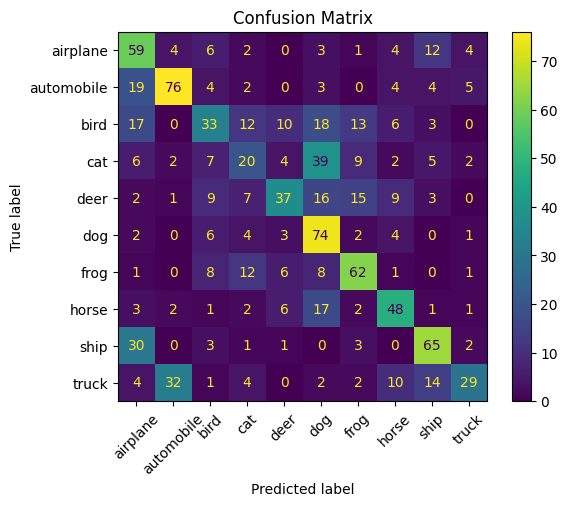

,precision,recall,f1-score,support
airplane,0.412587,0.621053,0.495798,95.000
automobile,0.649573,0.649573,0.649573,117.000
bird,0.423077,0.294643,0.347368,112.000
cat,0.303030,0.208333,0.246914,96.000
deer,0.552239,0.373737,0.445783,99.000
dog,0.411111,0.770833,0.536232,96.000
frog,0.568807,0.626263,0.596154,99.000
horse,0.545455,0.578313,0.561404,83.000
ship,0.607477,0.619048,0.613208,105.000
truck,0.644444,0.295918,0.405594,98.000


Macro Precision: 0.5118
Macro Recall:    0.5038
Macro F1-score:  0.4898


In [37]:

# Final test evaluation of the tuned model
_ = evaluate_on_test(
    final_tuned_model_result["model"],
    batch_size=best_tuned_config["batch_size"],
    eval_transform=eval_transform,
)


## 15. Transfer learning

Here we use a pretrained **ResNet-18** and compare:

- **freeze the backbone, train only the classifier head**
- **fine-tune the last residual block + classifier**


In [38]:

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

transfer_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transfer_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

TRANSFER_TRAIN_IDX = TRAIN_IDX[: min(len(TRAIN_IDX), 3000)]
TRANSFER_VAL_IDX = VAL_IDX[: min(len(VAL_IDX), 800)]
TRANSFER_TEST_IDX = TEST_IDX[: min(len(TEST_IDX), 800)]

def build_transfer_model(train_mode="freeze_head"):
    try:
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
    except Exception as e:
        print("Could not load pretrained weights.")
        print("If you are offline, skip this section or run it in Colab / an internet-enabled environment.")
        print("Original error:", e)
        return None

    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    if train_mode == "freeze_head":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True

    elif train_mode == "fine_tune_last_block":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    else:
        raise ValueError("train_mode must be 'freeze_head' or 'fine_tune_last_block'")

    return model.to(device)

def fit_transfer_model(model, train_loader, val_loader, epochs, lr, verbose=True):
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr)

    history = fit(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=epochs,
        device=device,
        scheduler=None,
        verbose=verbose,
    )
    return history


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 247MB/s]


Epoch 01/09 | train loss=1.8599 | val loss=1.3913 | train acc=0.3733 | val acc=0.5837 | lr=0.00100 | time=4.0s
Epoch 02/09 | train loss=1.1848 | val loss=1.0504 | train acc=0.6597 | val acc=0.6925 | lr=0.00100 | time=3.9s
Epoch 03/09 | train loss=0.9434 | val loss=0.9144 | train acc=0.7327 | val acc=0.7312 | lr=0.00100 | time=4.0s
Epoch 04/09 | train loss=0.8553 | val loss=0.8522 | train acc=0.7390 | val acc=0.7225 | lr=0.00100 | time=4.0s
Epoch 05/09 | train loss=0.7681 | val loss=0.8008 | train acc=0.7690 | val acc=0.7338 | lr=0.00100 | time=3.9s
Epoch 06/09 | train loss=0.7194 | val loss=0.7661 | train acc=0.7727 | val acc=0.7512 | lr=0.00100 | time=4.0s
Epoch 07/09 | train loss=0.6907 | val loss=0.7601 | train acc=0.7923 | val acc=0.7500 | lr=0.00100 | time=4.0s
Epoch 08/09 | train loss=0.6625 | val loss=0.7216 | train acc=0.7863 | val acc=0.7600 | lr=0.00100 | time=4.0s
Epoch 09/09 | train loss=0.6280 | val loss=0.7072 | train acc=0.8077 | val acc=0.7700 | lr=0.00100 | time=4.1s
E

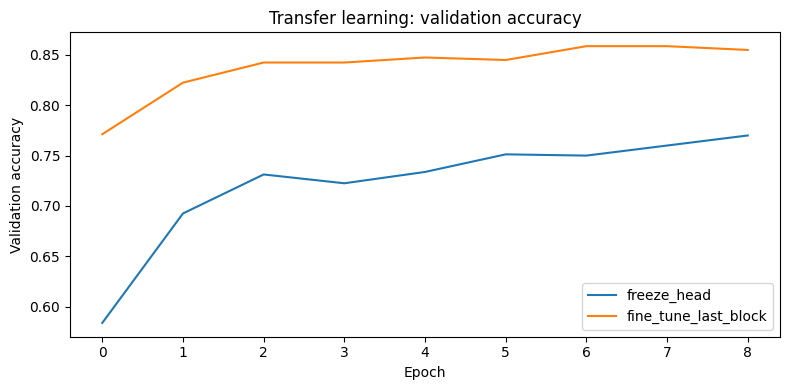

,run,best_epoch,best_val_acc,lr
1,fine_tune_last_block,8,0.85875,0.0001
0,freeze_head,9,0.77000,0.0010


Best transfer run: fine_tune_last_block
Transfer test loss: 0.4488
Transfer test accuracy: 0.8450


In [39]:

if RUN_TRANSFER_LEARNING:
    transfer_train_loader, transfer_val_loader, transfer_test_loader = build_loaders(
        batch_size=64,
        train_transform=transfer_train_transform,
        eval_transform=transfer_eval_transform,
        train_idx=TRANSFER_TRAIN_IDX,
        val_idx=TRANSFER_VAL_IDX,
        test_idx=TRANSFER_TEST_IDX,
    )

    transfer_results = {}

    for train_mode, lr in [("freeze_head", 1e-3), ("fine_tune_last_block", 1e-4)]:
        model = build_transfer_model(train_mode=train_mode)

        if model is not None:
            history = fit_transfer_model(
                model,
                transfer_train_loader,
                transfer_val_loader,
                epochs=max(2, CFG["base_epochs"] - 1),
                lr=lr,
                verbose=True,
            )

            transfer_results[train_mode] = {
                "model": model,
                "history": history,
                "config": {"train_mode": train_mode, "lr": lr},
            }

    if transfer_results:
        plt.figure(figsize=(8, 4))
        for name, result in transfer_results.items():
            plt.plot(result["history"]["val_acc"], label=name)
        plt.xlabel("Epoch")
        plt.ylabel("Validation accuracy")
        plt.title("Transfer learning: validation accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()

        summary_rows = []
        for name, result in transfer_results.items():
            summary_rows.append({
                "run": name,
                "best_epoch": result["history"]["best_epoch"],
                "best_val_acc": result["history"]["best_val_acc"],
                "lr": result["config"]["lr"],
            })
        display(pd.DataFrame(summary_rows).sort_values("best_val_acc", ascending=False))

        best_transfer_name = max(
            transfer_results, key=lambda k: transfer_results[k]["history"]["best_val_acc"]
        )
        best_transfer_model = transfer_results[best_transfer_name]["model"]

        criterion = nn.CrossEntropyLoss()
        test_loss, test_acc = evaluate(best_transfer_model, transfer_test_loader, criterion, device)
        print(f"Best transfer run: {best_transfer_name}")
        print(f"Transfer test loss: {test_loss:.4f}")
        print(f"Transfer test accuracy: {test_acc:.4f}")
else:
    print("Transfer learning is disabled. Set RUN_TRANSFER_LEARNING = True to run this section.")
